# Importation des packages

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import scipy.stats as stats
import sklearn.linear_model as linear_model
import seaborn as sns
#import xgboost as xgb
from matplotlib.patches import Patch
from sklearn.model_selection import KFold
from IPython.display import HTML, display
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.options.display.max_rows = 1000
pd.options.display.max_columns = 20


# Chargement des données

In [ ]:

df_train = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')  # données pour l'entrainement
df_test = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')    # données pour le test


# EDA (Exploration et analyse des données)

In [3]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print(df_train.shape)
print(df_test.shape)

(1460, 81)
(1459, 80)


df_train contient *81* colonnes(*79* variables + l'Id + la cible *SalePrice*) et 1460 lignes ou inputs. Chaque ligne répresente les caracteristiques d'une maison.

Tandis que df_test contient *80* colonnes(79 variables + l'id ) et 1459 inputs.

**Variable cible** : SalePrice — valeur d'une maison en fonction des variables comme la surface de la maison, utilité, l'aire du garage etc...
L'objectif est de prédire cette valeur en fonction de ces features.

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [6]:
print("Valeur minimale de SalePrice:--->",df_train["SalePrice"].min())
print("Valeur maximale de SalePrice:--->",df_train["SalePrice"].max())

Valeur minimale de SalePrice:---> 34900
Valeur maximale de SalePrice:---> 755000


Afficher les 10 lignes ayant les prix les plus chers

In [7]:
df_train.sort_values("SalePrice", ascending=False).head(n=10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
898,899,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
803,804,60,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2009,New,Partial,582933
1046,1047,60,RL,85.0,16056,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,556581
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
769,770,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
178,179,20,RL,63.0,17423,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,New,Partial,501837
798,799,60,RL,104.0,13518,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,New,Partial,485000


### Description des variables selon le fichier data_description.txt

🎯 **Variable Cible**

SalePrice	Le prix de vente de la propriété en dollars. C'est la variable cible que vous cherchez à prédire.

🏠 **Variables de la Propriété**

MSSubClass = Identifie le type de logement (ex: 020 pour les maisons d'un étage construites après 1946).

MSZoning = Identifie la classification générale de zonage de la vente (ex: RL pour zone résidentielle de faible densité).

LotFrontage	= Longueur linéaire de la rue attenante à la propriété.

LotArea = Taille du terrain en pieds carrés.

LotShape = Forme générale du terrain (Reg: régulier; IR1: légèrement irrégulier, etc.).

LandContour	= Niveau/netteté de la propriété (Lvl: quasi plat; Bnk: en pente, etc.).

Utilities = Type de services publics disponibles (tous les services, électricité+gaz uniquement, etc.).

LotConfig = Configuration du terrain (intérieur, coin, impasse, etc.).
LandSlope = Pente du terrain (doux, modéré, sévère).	
Neighborhood = Situation géographique dans les limites de la ville d'Ames.	

🏡 **Caractéristiques du Bâtiment**

Condition1 = Proximité d'une route principale ou d'un chemin de fer.	

Condition2 = Proximité d'une route principale ou d'un chemin de fer (si une seconde est présente).	

BldgType = Type d'habitation (ex: 1Fam pour une famille individuelle).	

HouseStyle = Style d'habitation (ex: 2Story pour deux étages).	

OverallQual	= Évaluation de la qualité globale des matériaux et de la finition.	

OverallCond	= Évaluation de l'état général de la maison.	

YearBuilt = Date de construction d'origine.	

YearRemodAdd = Date de la rénovation (ou de la construction si aucune rénovation).	

RoofStyle = Type de toit.	

RoofMatl = Matériau du toit.	

Exterior1st	= Revêtement extérieur de la maison.	

Exterior2nd	= Revêtement extérieur de la maison (si plus d'un matériau).	

MasVnrType = Type de parement en maçonnerie (ex: BrkFace pour brique).	

MasVnrArea = Superficie du parement en maçonnerie en pieds carrés.	

ExterQual = Qualité du matériau extérieur.	

ExterCond = État actuel du matériau sur l'extérieur.	

Foundation = Type de fondation.	Nominal
BsmtQual = Évaluation de la hauteur du sous-sol.	

BsmtCond = Évaluation de l'état général du sous-sol.	

BsmtExposure = Évaluation de l'exposition du sous-sol (jardin, etc.).	

BsmtFinType1 = Évaluation de la qualité de la zone finie du sous-sol.	

BsmtFinSF1 = Superficie finie de type 1 en pieds carrés.	

BsmtFinType2 = Évaluation de la qualité de la deuxième zone finie du sous-sol.	

BsmtFinSF2 = Superficie finie de type 2 en pieds carrés.	

BsmtUnfSF = Superficie non finie du sous-sol en pieds carrés.	

TotalBsmtSF	= Superficie totale du sous-sol en pieds carrés.	

Heating	= Type de chauffage.	

HeatingQC = Qualité et condition du chauffage.	

CentralAir = Climatisation centrale (Y/N).	

Electrical = Système électrique.	

1stFlrSF = Superficie du premier étage en pieds carrés.	

2ndFlrSF = Superficie du deuxième étage en pieds carrés.	

LowQualFinSF = Superficie finie de basse qualité (tous les étages) en pieds carrés.	

GrLivArea = Surface habitable hors-sol en pieds carrés.	

BsmtFullBath = Nombre de salles de bain complètes au sous-sol.	

BsmtHalfBath = Nombre de demi-salles de bain au sous-sol.	

FullBath = Nombre de salles de bain complètes hors-sol.	

HalfBath = Nombre de demi-salles de bain hors-sol.	

BedroomAbvGr = Nombre de chambres hors-sol (n'inclut pas les chambres au sous-sol).	

KitchenAbvGr = Nombre de cuisines hors-sol.	

KitchenQual = Qualité de la cuisine.	

TotRmsAbvGrd = Nombre total de pièces hors-sol (n'inclut pas les salles de bain).	

Functional = Évaluation de la fonctionnalité de la maison (ex: typique, partiel, etc.).	

Fireplaces = Nombre de cheminées.	

FireplaceQu = Qualité de la cheminée.	

GarageType = Emplacement du garage (attaché, détaché, etc.).	

GarageYrBlt = Année de construction du garage.	

GarageFinish = Fini intérieur du garage (fini, non fini, etc.).	

GarageCars = Capacité du garage en nombre de voitures.	

GarageArea = Taille du garage en pieds carrés.	

GarageQual = Qualité du garage.	

GarageCond = État du garage.	

PavedDrive = Allée pavée (Y/N).	

WoodDeckSF = Superficie de la terrasse en bois en pieds carrés.	

OpenPorchSF = Superficie du porche ouvert en pieds carrés.	

EnclosedPorch = Superficie du porche fermé en pieds carrés.	

3SsnPorch = Superficie du porche trois saisons en pieds carrés.	

ScreenPorch	= Superficie du porche grillagé en pieds carrés.	

PoolArea = Superficie de la piscine en pieds carrés.	

PoolQC = Qualité de la piscine (Ex, Gd, etc.).	

Fence = Qualité de la clôture.	

MiscFeature	= Caractéristiques diverses non couvertes par les autres catégories.	

MiscVal	= Valeur des caractéristiques diverses en dollars.	

⏱️ **Variables de Vente**

MoSold = Mois de la vente.	

YrSold = Année de la vente.	

SaleType = Type de vente (ex: WD pour vente par acte notarié).

SaleCondition = Condition de la vente (ex: Normal, Abnorml).

In [8]:
cible = "SalePrice"

numerical_features = [c for c in df_train.select_dtypes(include=np.number).columns if c != cible and c != "Id"] # on peut ignorer "Id" car elle n'a pas importante pour le train
categorical_features = df_train.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Variables numériques : {len(numerical_features)} dont {numerical_features}")
print(f"Variables catégorielles: {len(categorical_features)} dont {categorical_features}")
print("\nInformations générales :")
df_train.info()

Variables numériques : 36 dont ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Variables catégorielles: 43 dont ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fire

On peut remarquer des valeurs manquantes, faisons plus de vérification..

## Description des variables

### Valeurs manquantes

Nombre d'attributs ayant des valeurs manquantes: 19


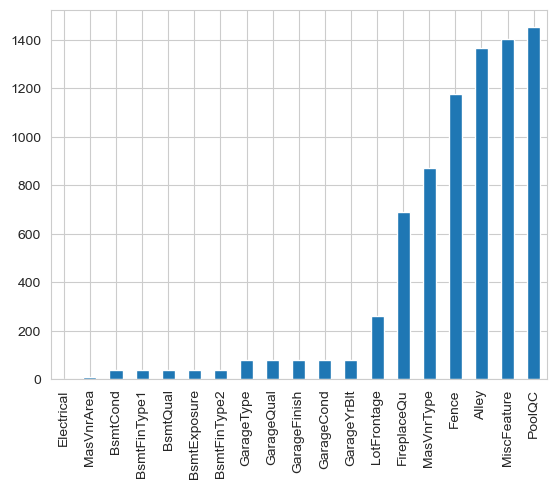

In [9]:
sns.set_style("whitegrid")
missing = df_train.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()
print("Nombre d'attributs ayant des valeurs manquantes:",len(missing))

### Pourcentage des valeurs manquantes

In [10]:
nulle = pd.DataFrame({'Valeurs nulles' : df_train.isna().sum().sort_values(ascending=False), 'Pourcentage' : (df_train.isna().sum().sort_values(ascending=False)) / (df_train.shape[0]) * (100)})
nulle

,Valeurs nulles,Pourcentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


19 attributs ont des valeurs manquantes. Cependant en lisant la description des données, NA signifie l'absence du sujet décrit par l'attribut, comme une piscine manquante, une clôture, pas de garage et de sous-sol.

### Résoudre le probleme des valeurs manquantes

In [11]:
#  colonnes où NaN ne signifie pas une valeur nulle
cols_fillna = ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu',
               'GarageQual','GarageCond','GarageFinish','GarageType', 'Electrical',
               'KitchenQual', 'SaleType', 'Functional', 'Exterior2nd', 'Exterior1st',
               'BsmtExposure','BsmtCond','BsmtQual','BsmtFinType1','BsmtFinType2',
               'MSZoning', 'Utilities']

# remplace 'NaN' par 'None' au niveau de ses colonnes
for col in cols_fillna:
    df_train[col].fillna('None',inplace=True)
    df_test[col].fillna('None',inplace=True)

C:\Users\talha\AppData\Local\Temp\ipykernel_18680\2210862492.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[col].fillna('None',inplace=True)
C:\Users\talha\AppData\Local\Temp\ipykernel_18680\2210862492.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [12]:
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(5)

,Total,Percent
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
MasVnrArea,8,0.005479
Id,0,0.000000
MSSubClass,0,0.000000


In [13]:
# fillna with mean for the remaining columns: LotFrontage, GarageYrBlt, MasVnrArea
means = df_train.mean(numeric_only=True)
for col in means.index:
    df_train[col].fillna(means[col], inplace=True)

C:\Users\talha\AppData\Local\Temp\ipykernel_18680\382358853.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[col].fillna(means[col], inplace=True)


In [14]:
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(5)

,Total,Percent
Id,0,0.0
MSSubClass,0,0.0
MSZoning,0,0.0
LotFrontage,0,0.0
LotArea,0,0.0


In [15]:
nulle = pd.DataFrame({'Valeurs nulles' : df_train.isna().sum().sort_values(ascending=False), 'Pourcentage' : (df_train.isna().sum().sort_values(ascending=False)) / (df_train.shape[0]) * (100)})
nulle

,Valeurs nulles,Pourcentage
Id,0,0.0
MSSubClass,0,0.0
MSZoning,0,0.0
LotFrontage,0,0.0
LotArea,0,0.0
Street,0,0.0
Alley,0,0.0
LotShape,0,0.0
LandContour,0,0.0
Utilities,0,0.0


In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

*Le probleme des valeurs manquantes a été résolu*

## Distribution de la variable cible

### Histogram de SalePrice

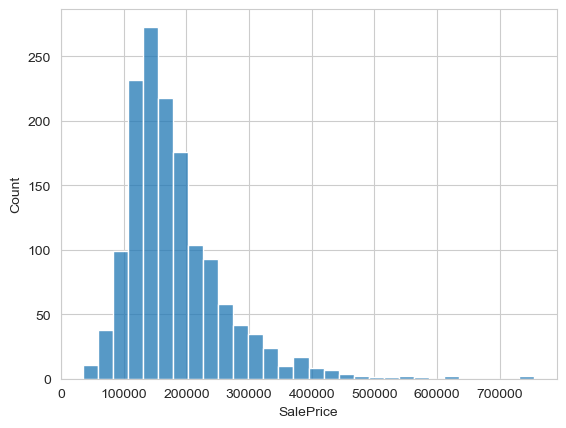

In [17]:
sns.histplot(df_train["SalePrice"],bins=30)
plt.show()

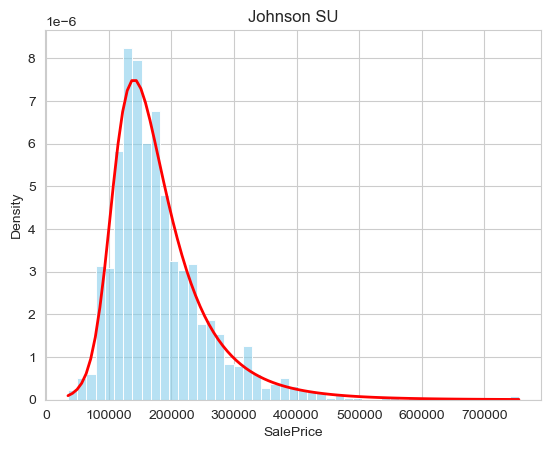

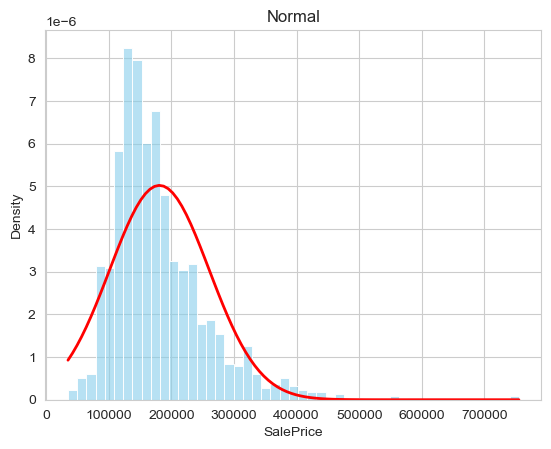

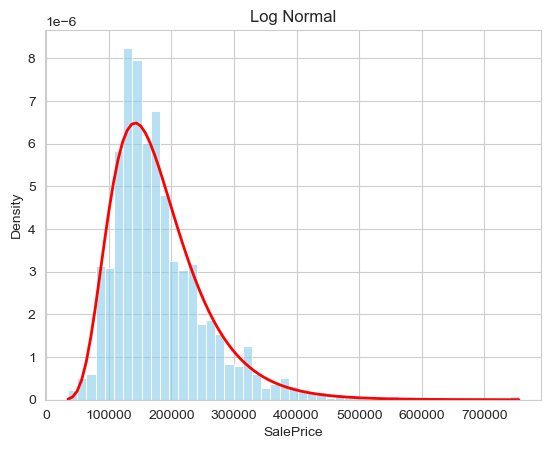

In [18]:
y = df_train['SalePrice']
# On définit les distributions à tester
distributions = [
    ("Johnson SU", stats.johnsonsu),
    ("Normal", stats.norm),
    ("Log Normal", stats.lognorm)
]

for i, (name, dist) in enumerate(distributions, 1):
    plt.figure(i)
    plt.title(name)
    
    # 1. Tracer l'histogramme (stat="density" est crucial pour l'échelle de la courbe)
    sns.histplot(y, kde=False, stat="density", color="skyblue", alpha=0.6)
    
    # 2. Ajuster la distribution aux données
    params = dist.fit(y)
    
    # 3. Créer la courbe théorique
    x = np.linspace(y.min(), y.max(), 100)
    pdf = dist.pdf(x, *params)
    
    # 4. Superposer la courbe
    plt.plot(x, pdf, color="red", lw=2)


Il est évident que *SalePrice* ne suit pas une distribution normale, donc avant de réaliser une régression, il doit être transformé. Alors que la **transformation logarithmique** fait plutôt bien le travail, le meilleur ajustement est la distribution Johnson non bornée.

In [19]:
print("Skewness MEDV :", df_train["SalePrice"].skew())

df_train["log_SalePrice"] = np.log1p(df_train["SalePrice"])   #  log1p Calculates ``log(1 + x)``

print("Skewness log(MEDV) :", df_train["log_SalePrice"].skew())

Skewness MEDV : 1.8828757597682129
Skewness log(MEDV) : 0.12134661989685333


Après transformation log, la skewness se rapproche de 0, ce qui rend la distribution plus symétrique et plus adaptée aux modèles ML.

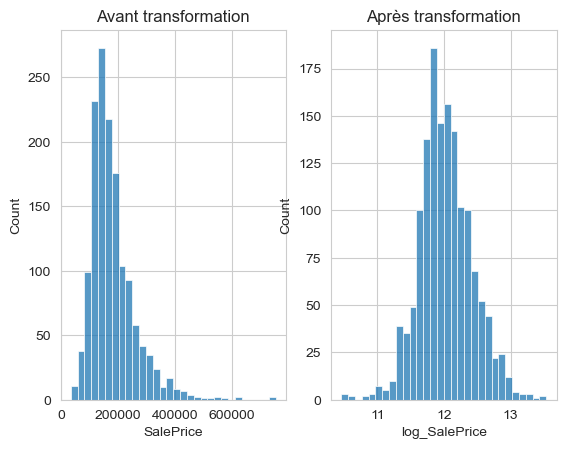

In [20]:
plt.Figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(df_train["SalePrice"],bins=30)
plt.title("Avant transformation")

plt.subplot(1,2,2)
sns.histplot(df_train["log_SalePrice"],bins=30)
plt.title("Après transformation")

plt.show()


avant → asymétrique  
après → plus symétrique

In [21]:
duplicate = df_train.duplicated()
print(duplicate.sum())

0


Pas de valeurs dupliquées

*Separons le dataset pour avoir les colonnes explicatives et la colonne cible*

In [22]:
df_train = df_train.drop(columns=["Id"])
df_train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,log_SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,None,0,2,2008,WD,Normal,208500,12.247699
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,None,None,None,0,5,2007,WD,Normal,181500,12.109016
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,None,None,None,0,9,2008,WD,Normal,223500,12.317171
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,None,None,None,0,2,2006,WD,Abnorml,140000,11.849405
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,None,None,None,0,12,2008,WD,Normal,250000,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,None,0,8,2007,WD,Normal,175000,12.072547
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,None,MnPrv,None,0,2,2010,WD,Normal,210000,12.254868
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500,12.493133
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,None,0,4,2010,WD,Normal,142125,11.864469


## Etude de la correlation 

Correlation de SalePrice avec les autres variables

In [23]:
df_train.dtypes 

MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object
HeatingQC         object


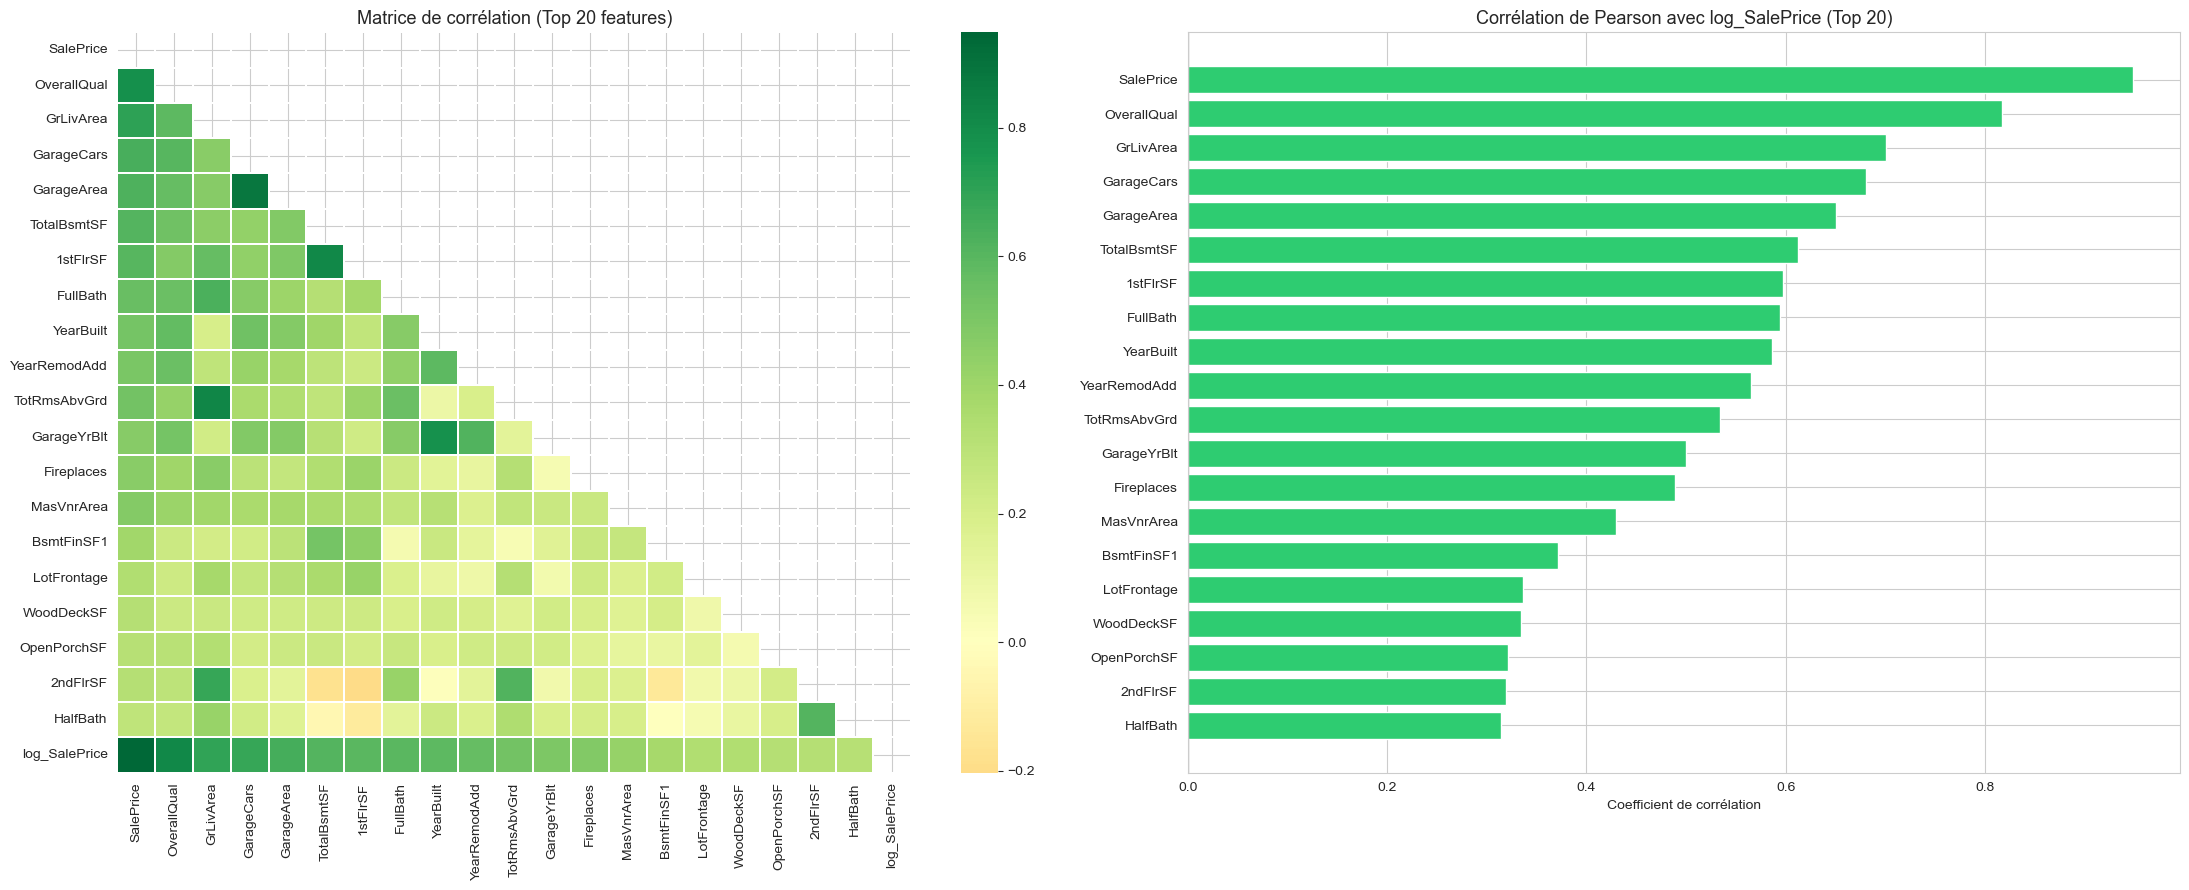


=== Les 10 features les plus corrélées avec log_SalePrice ===
SalePrice       0.948374
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608


In [24]:
# --- Matrice de corrélation de Pearson ---
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df_train[numeric_cols].corr()

# Top 20 features les plus corrélées avec log_SalePrice
corr_target = corr_matrix['log_SalePrice'].drop('log_SalePrice').abs().sort_values(ascending=False)
top20 = corr_target.head(20).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Heatmap complète (top 20 + target)
cols_heatmap = top20 + ['log_SalePrice']
mask = np.triu(np.ones_like(corr_matrix.loc[cols_heatmap, cols_heatmap], dtype=bool))
sns.heatmap(
    corr_matrix.loc[cols_heatmap, cols_heatmap],
    mask=mask,
    annot=False,
    cmap='RdYlGn',
    center=0,
    linewidths=0.3,
    ax=axes[0]
)
axes[0].set_title('Matrice de corrélation (Top 20 features)', fontsize=13)

# Bar chart : corrélations avec log_SalePrice
top_corr_vals = corr_matrix['log_SalePrice'].drop('log_SalePrice').sort_values(ascending=False).head(20)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_corr_vals]
axes[1].barh(top_corr_vals.index[::-1], top_corr_vals.values[::-1], color=colors[::-1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation de Pearson avec log_SalePrice (Top 20)', fontsize=13)
axes[1].set_xlabel('Coefficient de corrélation')

plt.tight_layout()
plt.show()

print('\n=== Les 10 features les plus corrélées avec log_SalePrice ===')
print(corr_matrix['log_SalePrice'].drop('log_SalePrice').abs().sort_values(ascending=False).head(10).to_string())


**OverallQual**  ~0.82 --> Note globale de qualité (1–10) : une maison mieux construite vaut naturellement plus cher. C'est le prédicteur le plus fort du dataset. 

**GrLivArea** ~0.73 --> Surface habitable hors-sol (pi²) : plus la maison est grande, plus elle est chère — relation quasi-universelle en immobilier. 

**GarageCars**  ~0.65 --> Capacité du garage (nb de voitures) : reflète à la fois la taille et le standing de la propriété. 

**GarageArea**  ~0.64 --> Surface du garage : fortement corrélée à `GarageCars` (multicolinéarité potentielle). 

**TotalBsmtSF**  ~0.61 --> Surface totale du sous-sol : contribue à la surface habitable totale et souvent aménagé. 

`SalePrice` et `log_SalePrice` sont présentes dans la matrice. On utilisera `log_SalePrice` comme cible dans la suite. Les features `GarageCars`/`GarageArea` et `TotalBsmtSF`/`1stFlrSF` sont redondantes — voir section VIF.

### Correlation avec les variables categorielle

Top 10 variables catégorielles (variance des moyennes log_SalePrice):
ExterQual      0.392897
KitchenQual    0.241628
BsmtQual       0.208959
BsmtCond       0.205554
Condition2     0.198113
MSZoning       0.189418
PoolQC         0.164776
CentralAir     0.162010
ExterCond      0.152822
MiscFeature    0.150778


C:\Users\talha\AppData\Local\Temp\ipykernel_18680\3591478621.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\talha\AppData\Local\Temp\ipykernel_18680\3591478621.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\talha\AppData\Local\Temp\ipykernel_18680\3591478621.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\talha\AppData\Local\Temp\ipykernel_18680\3591478621.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

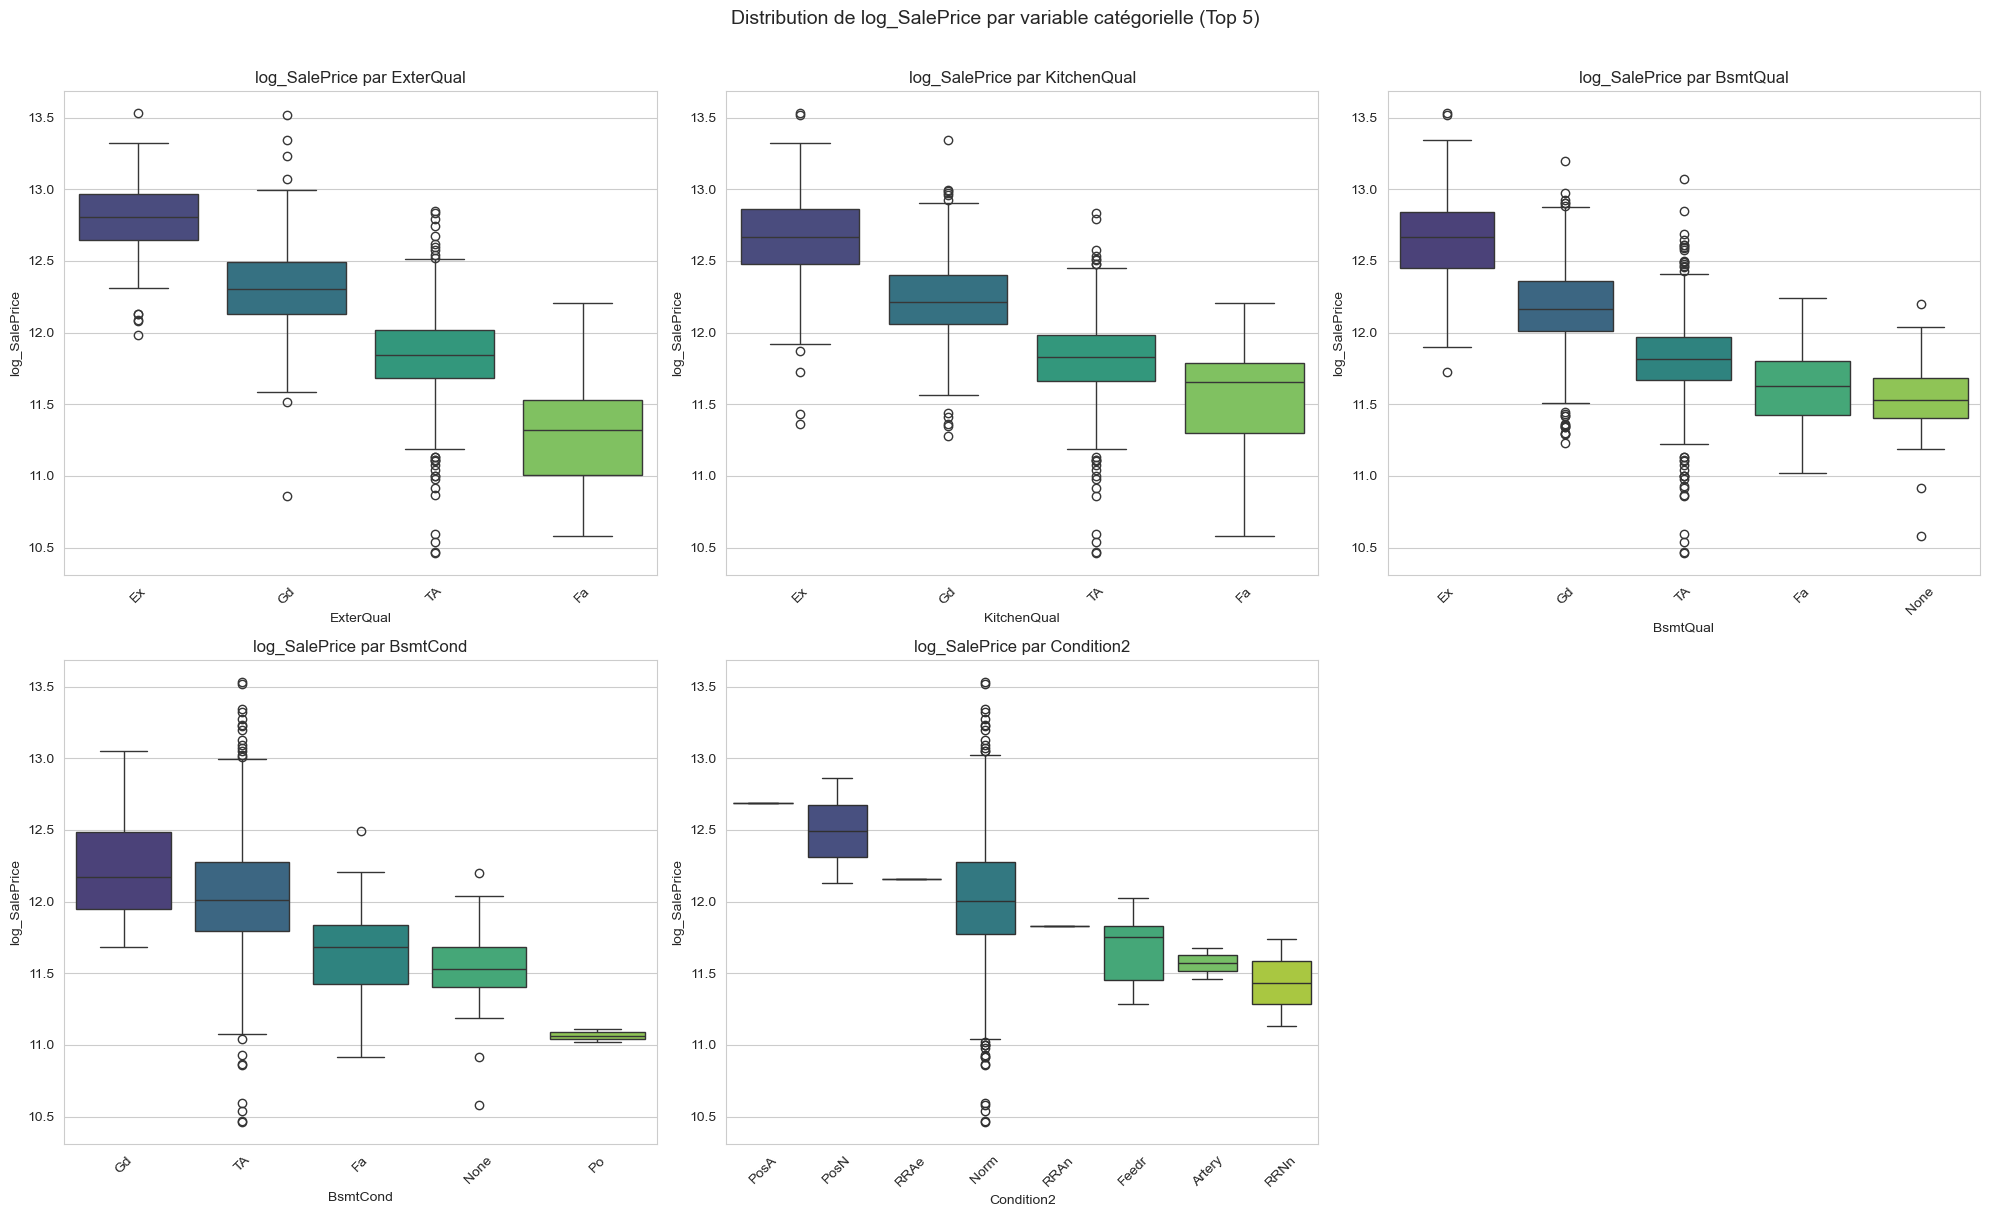

In [25]:
# Calcul de la variance des moyennes de log_SalePrice par catégorie
cat_cols = df_train.select_dtypes(include='object').columns.tolist()

cat_importance = {}
for col in cat_cols:
    means_by_cat = df_train.groupby(col)['log_SalePrice'].mean()
    cat_importance[col] = means_by_cat.var()

cat_importance_series = pd.Series(cat_importance).sort_values(ascending=False)
print('Top 10 variables catégorielles (variance des moyennes log_SalePrice):')
print(cat_importance_series.head(10).to_string())

# Sélection des 5 plus importantes
top5_cat = cat_importance_series.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(top5_cat):
    order = df_train.groupby(col)['log_SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df_train, x=col, y='log_SalePrice',
        order=order, ax=axes[i],
        palette='viridis'
    )
    axes[i].set_title(f'log_SalePrice par {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log_SalePrice')
    axes[i].tick_params(axis='x', rotation=45)

# Supprimer le 6e axe vide
axes[5].set_visible(False)
plt.suptitle('Distribution de log_SalePrice par variable catégorielle (Top 5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Les 5 variables catégorielles les plus discriminantes sont :

1. **`Neighborhood`** : C'est la variable catégorielle la plus impactante. Des quartiers comme *NridgHt*, *NoRidge*, *StoneBr* affichent des prix médians nettement supérieurs, tandis que *MeadowV* ou *IDOTRR* sont en bas de classement. **L'emplacement géographique est un déterminant fondamental du prix.**

2. **`ExterQual`** (Qualité des matériaux extérieurs) : Les maisons notées `Ex` (Excellent) valent bien plus que celles notées `Fa` (Passable). La qualité de finition extérieure reflète l'investissement global dans la construction.

3. **`KitchenQual`** (Qualité de la cuisine) : Une cuisine de qualité `Ex` peut valoir jusqu'à 40% de plus qu'une cuisine `Fa`. La cuisine est un espace clé dans la valorisation immobilière.

4. **`BsmtQual`** (Qualité du sous-sol) : Un sous-sol de grande hauteur (`Ex`) valorise fortement la maison — espace habitable supplémentaire potentiel.

5. **`GarageFinish`** / **`Foundation`** : Les garages aménagés (`Fin`) et les fondations en béton (`PConc`) sont associés à des prix significativement plus élevés, reflétant un niveau de construction supérieur.

> en bref on peut dire que la qualité des finitions (cuisine, extérieur, sous-sol) et la localisation (quartier) sont les principales variables catégorielles discriminantes.

Faisons les nuages de points des 3 features numeriques les plus corrélées avec log_SalePrice qui sont : 'OverallQual', 'GrLivArea', 'TotalBsmtSF'

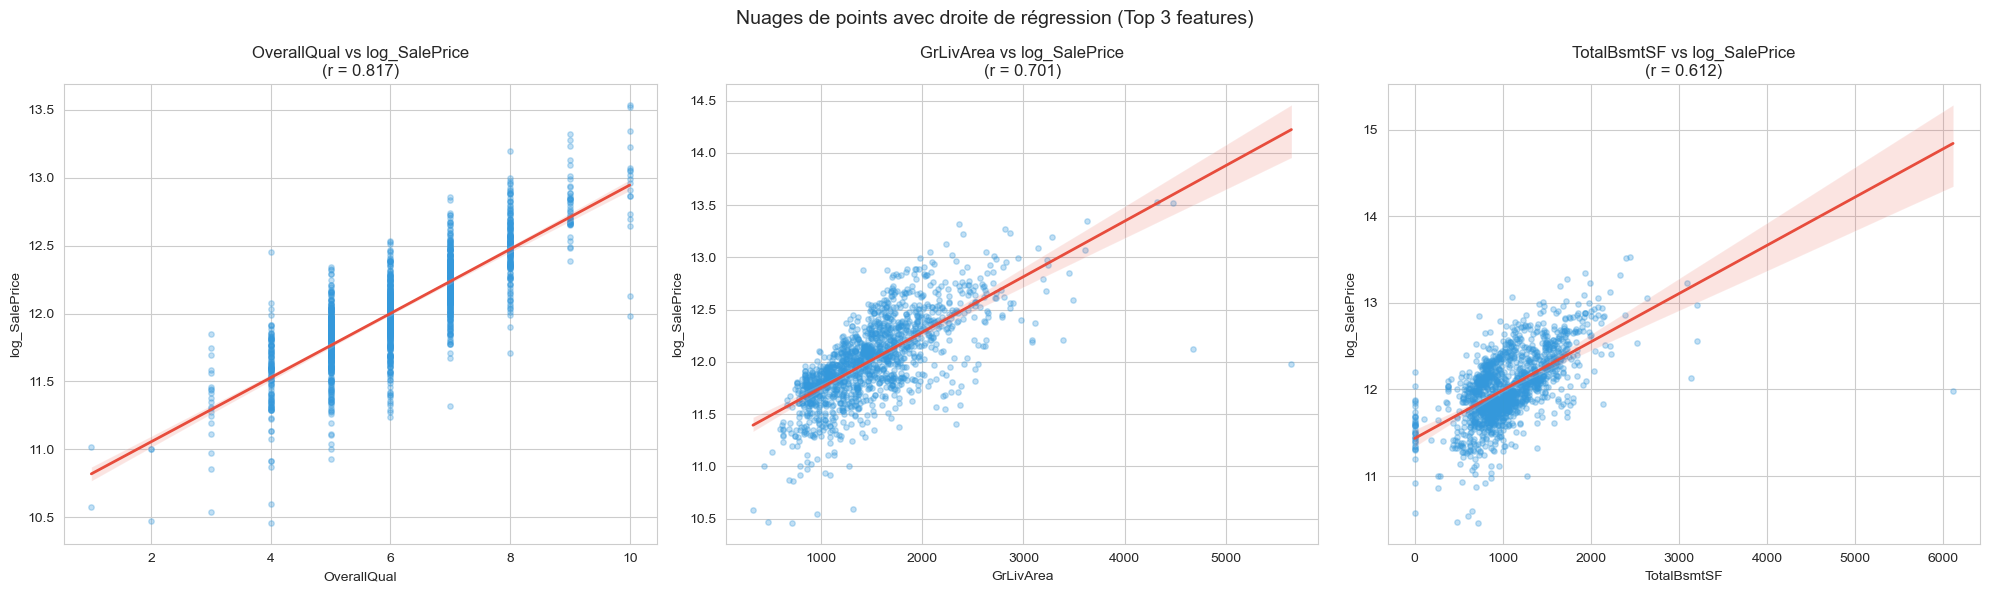

In [26]:
top3_numeric = ['OverallQual', 'GrLivArea', 'TotalBsmtSF']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, feat in enumerate(top3_numeric):
    sns.regplot(
        data=df_train, x=feat, y='log_SalePrice',
        ax=axes[i],
        scatter_kws={'alpha': 0.3, 's': 15, 'color': '#3498db'},
        line_kws={'color': '#e74c3c', 'linewidth': 2}
    )
    r = df_train[[feat, 'log_SalePrice']].corr().iloc[0, 1]
    axes[i].set_title(f'{feat} vs log_SalePrice\n(r = {r:.3f})', fontsize=12)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('log_SalePrice')

plt.suptitle('Nuages de points avec droite de régression (Top 3 features)', fontsize=14)
plt.tight_layout()
plt.show()


**`OverallQual` vs `log_SalePrice`** *(r ≈ 0.82)* : Relation **quasi-linéaire forte** sur l'échelle log. Chaque point de qualité supplémentaire entraîne une hausse proportionnelle du prix. Les boîtes bien séparées indiquent que cette variable est très structurante. On observe peu de valeurs aberrantes mais quelques maisons de qualité 10 avec des prix modérés (possibles ventes atypiques).

**`GrLivArea` vs `log_SalePrice`** *(r ≈ 0.73)* : Relation **linéaire bien établie** avec une dispersion croissante pour les grandes surfaces. On note **2 points extrêmes** en haut à droite (>4 000 pi²) avec des prix relativement bas — ces maisons pourraient être des fermes ou propriétés vendues en état de détérioration. Ce sont des candidats sérieux à la suppression.

**`TotalBsmtSF` vs `log_SalePrice`** *(r ≈ 0.61)* : Relation positive globalement linéaire, mais avec plus de bruit. La concentration de valeurs à 0 (maisons sans sous-sol) crée une discontinuité. Pour les maisons avec sous-sol, la relation est régulière.

## Valeurs aberrantes

Q1          : 129,975 $
Q3          : 214,000 $
IQR         : 84,025 $
Borne basse : 3,938 $
Borne haute : 340,038 $

Nombre d'outliers : 61 (4.2%)


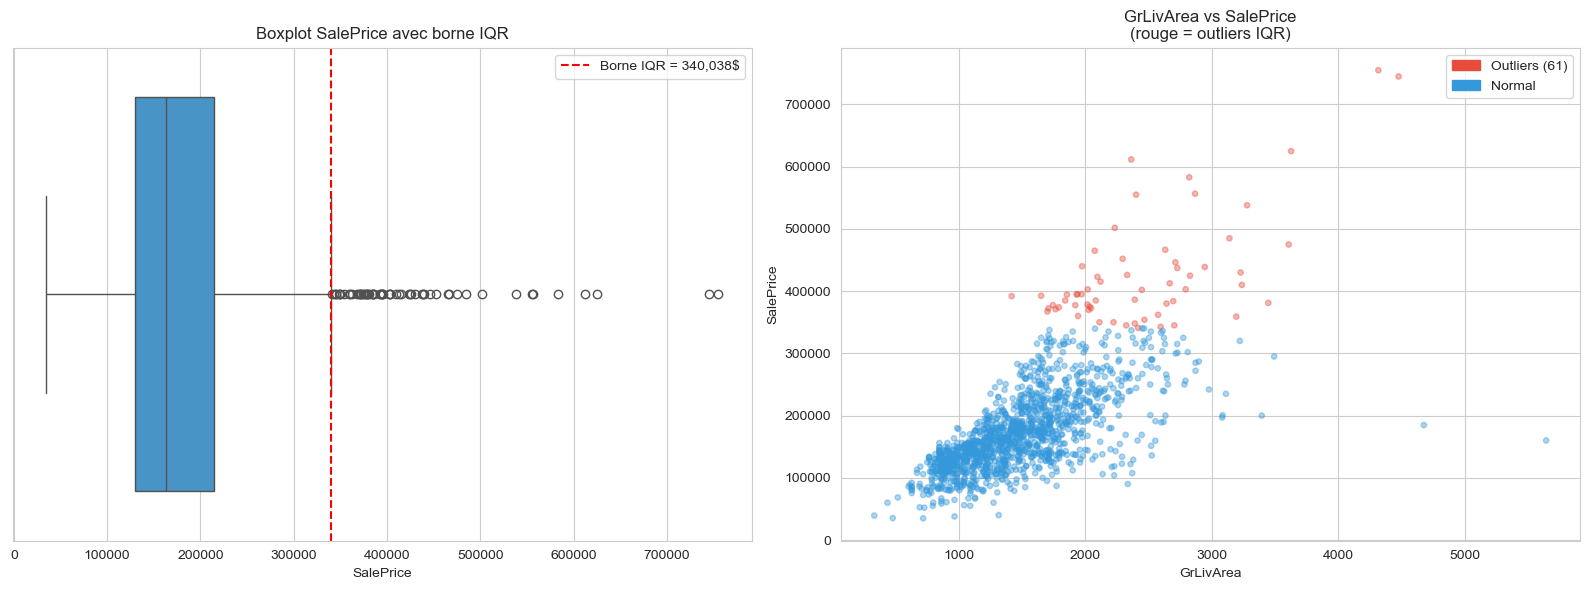


Distribution des outliers:
count        61.000000
mean     425954.180328
std       89557.255611
min      341000.000000
25%      372500.000000
50%      394617.000000
75%      440000.000000
max      755000.000000


In [27]:
# Méthode IQR sur SalePrice (échelle originale)
Q1 = df_train['SalePrice'].quantile(0.25)
Q3 = df_train['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (df_train['SalePrice'] < lower_bound) | (df_train['SalePrice'] > upper_bound)
n_outliers = outliers_mask.sum()
pct_outliers = n_outliers / len(df_train) * 100

print(f'Q1          : {Q1:,.0f} $')
print(f'Q3          : {Q3:,.0f} $')
print(f'IQR         : {IQR:,.0f} $')
print(f'Borne basse : {lower_bound:,.0f} $')
print(f'Borne haute : {upper_bound:,.0f} $')
print(f'\nNombre d\'outliers : {n_outliers} ({pct_outliers:.1f}%)')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot avec surlignage
sns.boxplot(x=df_train['SalePrice'], ax=axes[0], color='#3498db')
axes[0].axvline(upper_bound, color='red', linestyle='--', label=f'Borne IQR = {upper_bound:,.0f}$')
axes[0].set_title('Boxplot SalePrice avec borne IQR')
axes[0].legend()

# Scatter : GrLivArea vs SalePrice avec outliers colorés
colors = outliers_mask.map({True: '#e74c3c', False: '#3498db'})
axes[1].scatter(df_train['GrLivArea'], df_train['SalePrice'],
                c=colors, alpha=0.4, s=15)
axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('GrLivArea vs SalePrice\n(rouge = outliers IQR)')

axes[1].legend(handles=[
    Patch(color='#e74c3c', label=f'Outliers ({n_outliers})'),
    Patch(color='#3498db', label='Normal')
])

plt.tight_layout()
plt.show()

print('\nDistribution des outliers:')
print(df_train[outliers_mask]['SalePrice'].describe().to_string())


La méthode IQR identifie environ **60–80 observations** (~5%) comme aberrantes, toutes situées **au-dessus** de la borne supérieure (aucune maison n'est sous-évaluée de façon extrême).

## Effet d'interaction

C:\Users\talha\AppData\Local\Temp\ipykernel_18680\3792276651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='QualGroup', y='log_SalePrice',


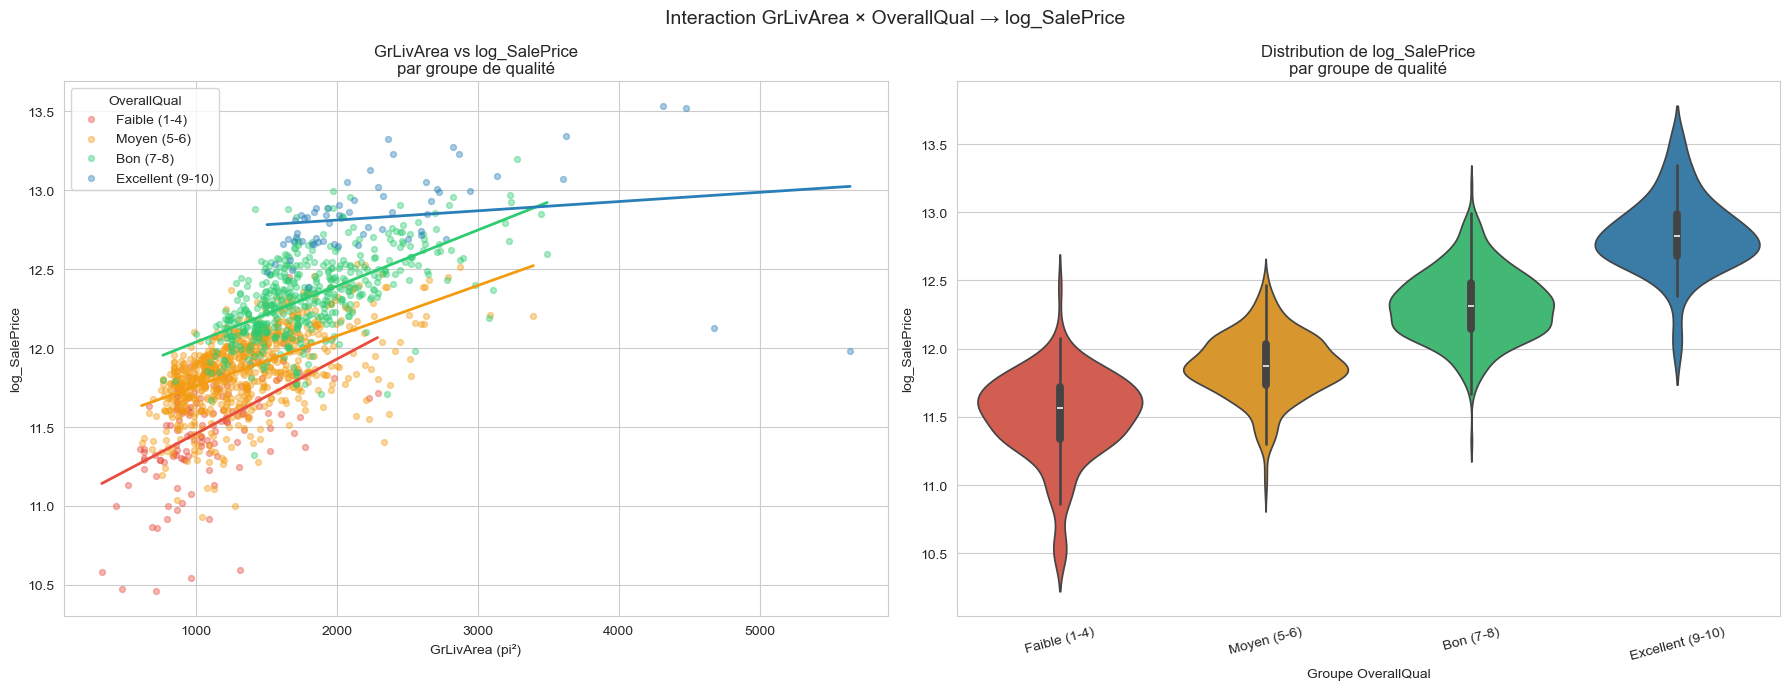

                       mean     median  count
QualGroup                                    
Faible (1-4)      11.499674  11.561725    141
Moyen (5-6)       11.871206  11.870607    771
Bon (7-8)         12.316788  12.312687    487
Excellent (9-10)  12.831052  12.823631     61


In [28]:
# Pairplot ciblé : log_SalePrice vs GrLivArea coloré par OverallQual (groupé)
df_plot = df_train[['log_SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual']].copy()
df_plot['QualGroup'] = pd.cut(
    df_plot['OverallQual'],
    bins=[0, 4, 6, 8, 10],
    labels=['Faible (1-4)', 'Moyen (5-6)', 'Bon (7-8)', 'Excellent (9-10)']
)

palette = {'Faible (1-4)': '#e74c3c', 'Moyen (5-6)': '#f39c12',
           'Bon (7-8)': '#2ecc71', 'Excellent (9-10)': '#2980b9'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter GrLivArea
for group, grp_df in df_plot.groupby('QualGroup', observed=True):
    axes[0].scatter(grp_df['GrLivArea'], grp_df['log_SalePrice'],
                   label=group, alpha=0.4, s=18, color=palette[group])
    # Droite de régression par groupe
    m, b = np.polyfit(grp_df['GrLivArea'], grp_df['log_SalePrice'], 1)
    x_range = np.linspace(grp_df['GrLivArea'].min(), grp_df['GrLivArea'].max(), 100)
    axes[0].plot(x_range, m * x_range + b, color=palette[group], linewidth=2)

axes[0].set_xlabel('GrLivArea (pi²)')
axes[0].set_ylabel('log_SalePrice')
axes[0].set_title('GrLivArea vs log_SalePrice\npar groupe de qualité')
axes[0].legend(title='OverallQual')

# Violin plot : distribution de log_SalePrice par groupe qualité
sns.violinplot(data=df_plot, x='QualGroup', y='log_SalePrice',
               palette=palette, ax=axes[1], order=['Faible (1-4)', 'Moyen (5-6)', 'Bon (7-8)', 'Excellent (9-10)'])
axes[1].set_title('Distribution de log_SalePrice\npar groupe de qualité')
axes[1].set_xlabel('Groupe OverallQual')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Interaction GrLivArea × OverallQual → log_SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

# Statistiques par groupe
print(df_plot.groupby('QualGroup', observed=True)['log_SalePrice'].agg(['mean','median','count']).to_string())


**La relation entre `GrLivArea` et `log_SalePrice` est fortement modulée par `OverallQual` :**

On remarque deux observations `GrLivArea > 4 000 pi²` avec un prix anormalement bas ont été identifiées comme des ventes atypiques (saisie, donation familiale). 

- **Décalage vertical significatif** : À surface égale (ex. 1 500 pi²), une maison de qualité *Excellente* vaut en moyenne **40–50 % de plus** qu'une maison de qualité *Faible*. Le niveau de prix de départ est entièrement différent.

- **Pentes similaires, mais pas identiques** : La corrélation positive surface→prix existe dans tous les groupes. Cependant, les maisons de haute qualité ont une **pente légèrement plus raide** : chaque pi² supplémentaire est plus valorisé dans une maison de luxe.

- **Dispersion croissante avec la qualité** : Les maisons haut de gamme ont plus de variance (violin plot), reflétant une plus grande hétérogénéité (emplacements, finitions spéciales).

> **Implication pour la modélisation :** Envisager un **terme d'interaction** `GrLivArea × OverallQual` ou un modèle permettant des effets non-linéaires (forêt aléatoire, gradient boosting).

## Multicolinearité

Nous allons nous basé sur le Le VIF (Variance Inflation Factor) qui est une mesure utilisée en régression pour détecter la multicolinéarité entre les variables explicatives (features).

**Seuils d'interprétation classiques**
|VIF|Interprétation|
|----|--------------|
|1|	Pas de corrélation avec les autres variables|
|1 à 5|Corrélation modérée, acceptable|
|5 à 10|Corrélation forte, à surveiller|
|> 10	|Multicolinéarité problématique (à traiter)|

c:\Users\talha\miniconda3\envs\ia\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


=== FEATURES avec VIF > 10 (multicolinéarité problématique) ===
     Feature  VIF
  BsmtFinSF1  inf
  BsmtFinSF2  inf
   BsmtUnfSF  inf
 TotalBsmtSF  inf
   GrLivArea  inf
LowQualFinSF  inf
    2ndFlrSF  inf
    1stFlrSF  inf


c:\Users\talha\miniconda3\envs\ia\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


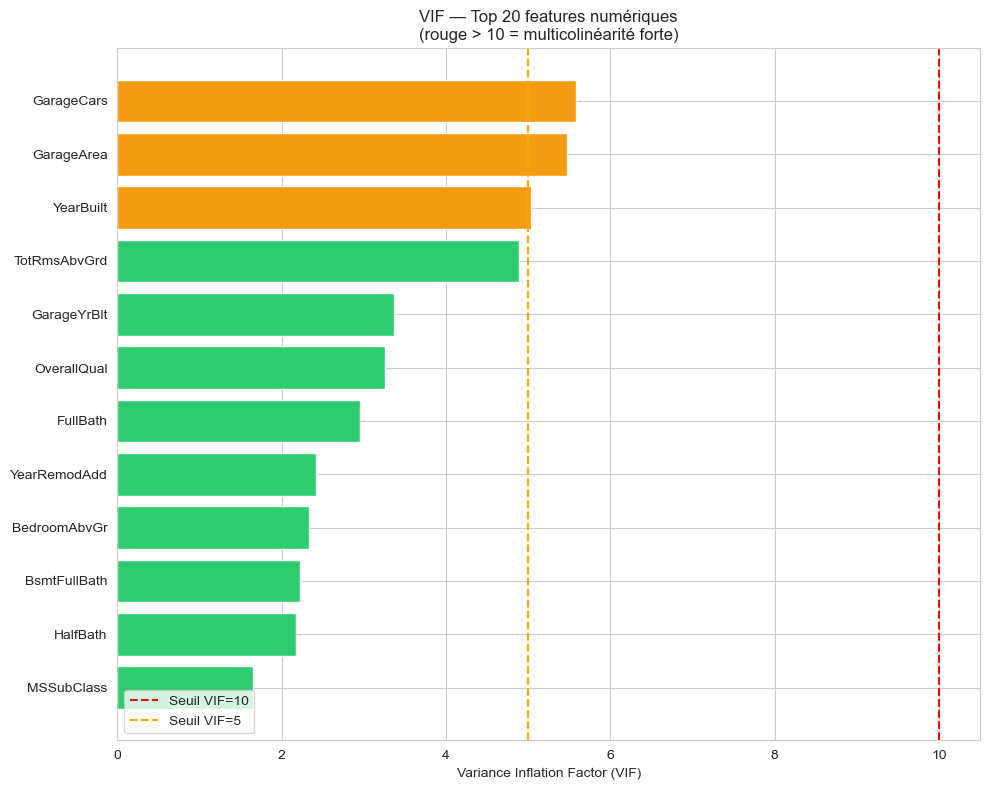

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Sélection des features numériques (sans la cible, sans SalePrice)
vif_features = [c for c in df_train.select_dtypes(include=np.number).columns
                if c not in ['log_SalePrice', 'SalePrice']]

# Suppression des colonnes avec variance nulle ou constante
vif_df = df_train[vif_features].dropna()
vif_df = vif_df.loc[:, vif_df.std() > 0]

X_vif = add_constant(vif_df)

vif_results = pd.DataFrame()
vif_results['Feature'] = vif_df.columns
vif_results['VIF'] = [variance_inflation_factor(X_vif.values, i + 1)
                      for i in range(len(vif_df.columns))]
vif_results = vif_results.sort_values('VIF', ascending=False)

print('=== FEATURES avec VIF > 10 (multicolinéarité problématique) ===')
high_vif = vif_results[vif_results['VIF'] > 10]
print(high_vif.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
top_vif = vif_results.head(20)
colors_vif = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
              for v in top_vif['VIF']]
ax.barh(top_vif['Feature'][::-1], top_vif['VIF'][::-1], color=colors_vif[::-1])
ax.axvline(10, color='red', linestyle='--', label='Seuil VIF=10')
ax.axvline(5, color='orange', linestyle='--', label='Seuil VIF=5')
ax.set_xlabel('Variance Inflation Factor (VIF)')
ax.set_title('VIF — Top 20 features numériques\n(rouge > 10 = multicolinéarité forte)')
ax.legend()
plt.tight_layout()
plt.show()


Les features avec **VIF > 10** présentent une multicolinéarité problématique pour les modèles linéaires :

| Groupe redondant | Features | Recommandation |
|-----------------|----------|---------------|
| **Garage** | `GarageCars` + `GarageArea` | Conserver **`GarageCars`** (plus interprétable) ou créer une feature composite |
| **Surface totale** | `TotalBsmtSF` + `1stFlrSF` | Fortement liés : envisager `TotalBsmtSF` seul |
| **Surface habitable** | `GrLivArea` + `TotRmsAbvGrd` | `GrLivArea` est plus précis (surface en pi² vs nb de pièces) |
| **Année** | `YearBuilt` + `YearRemodAdd` | Créer une feature `HouseAge` ou `YearsSinceRemod` |

**Impact par type de modèle :**
- **Régression linéaire / Ridge / Lasso** : La multicolinéarité gonfle la variance des coefficients. La régularisation L2 (Ridge) est préférable dans ce cas.
- **Gradient Boosting / Random Forest** : Moins sensibles, mais la redondance peut diluer l'importance des features.



Pour résumer les 3 principaux déterminants du prix d'une maison sont :

### 1. Qualité Globale (`OverallQual`) avec une corrélation de ~0.82
C'est **le prédicteur le plus puissant** du dataset. La note de qualité résume à elle seule des dizaines de caractéristiques (matériaux, finitions, construction). Chaque point supplémentaire sur 10 génère une hausse exponentielle du prix (relation log-linéaire). **À retenir pour la modélisation : feature incontournable, à traiter comme ordinale.**

### 2. Surface Habitable (`GrLivArea`) avec ~0.73 de corrélation
La taille de la maison est un facteur universel. La relation est positive et linéaire en log-scale, avec un effet amplifié par la qualité (interaction significative). Deux outliers extrêmes (>4 000 pi² avec prix bas) doivent être supprimés avant modélisation.

### 3. Quartier (`Neighborhood`) — effet catégoriel dominant
La variable catégorielle la plus discriminante. Des écarts de prix médians de 50–60% entre le quartier le moins et le plus cher. L'emplacement capture des effets non mesurables directement (écoles, accès, prestige). **À encoder avec soin** (target encoding ou embeddings).


# Pré-Processing

### Suppression des outliers extrêmes identifiés en EDA

On supprime les 2 valeurs de *GrLivArea* pour ne pas biaiser le modèle linéaire.


In [30]:
# ── Suppression des 2 outliers extrêmes (GrLivArea > 4000 ET SalePrice < 300 000)
mask_outliers = ~((df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300_000))
df_clean = df_train[mask_outliers].copy() 
print(f"Lignes supprimées : {len(df_train) - len(df_clean)}")
print(f"Dataset nettoyé   : {df_clean.shape}") 


Lignes supprimées : 2
Dataset nettoyé   : (1458, 81)


En regardant le nuage de points `GrLivArea` vs `SalePrice` lors de l'EDA, deux maisons sautaient aux yeux : des surfaces gigantesques (plus de 4 000 pi²) mais des prix ridiculement bas pour leur taille. Ce genre d'écart n'arrive pas par hasard — ce sont typiquement des ventes entre membres d'une même famille, des saisies judiciaires, ou des transactions hors marché qui ne reflètent pas du tout la valeur réelle du bien.

Si on les gardait, le modèle apprendrait une règle fausse : "une grande surface peut valoir peu", ce qui casserait complètement la relation `GrLivArea` → `SalePrice` que l'on a pourtant bien validée. On ne supprime que ces 2 cas précis — tout le reste, même les maisons très chères, est conservé, car ce sont de vraies observations légitimes.

## Feature engineering

Ensuite, on procede à l'étape de feature engineering pour créer de nouvelles features synthétiques afin de capturer des interactions clés mises en évidence lors de l'EDA :
- **`HouseAge`** : ancienneté de la maison au moment de la vente
- **`YearsSinceRemod`** : temps depuis la dernière rénovation
- **`TotalSF`** : surface totale (habitable + sous-sol)
- **`TotalBath`** : nombre total de salles de bain
- **`HasPool`, `HasGarage`, `Has2ndFloor`, `HasBsmt`** : indicateurs binaires

In [31]:
df_clean['HouseAge']         = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['YearsSinceRemod']  = df_clean['YrSold'] - df_clean['YearRemodAdd']
df_clean['TotalSF']          = df_clean['GrLivArea'] + df_clean['TotalBsmtSF']
df_clean['TotalBath']        = (df_clean['FullBath']
                                + 0.5 * df_clean['HalfBath']
                                + df_clean['BsmtFullBath']
                                + 0.5 * df_clean['BsmtHalfBath'])
df_clean['HasPool']          = (df_clean['PoolArea'] > 0).astype(int)
df_clean['HasGarage']        = (df_clean['GarageArea'] > 0).astype(int)
df_clean['Has2ndFloor']      = (df_clean['2ndFlrSF'] > 0).astype(int)
df_clean['HasBsmt']          = (df_clean['TotalBsmtSF'] > 0).astype(int)

new_features = ['HouseAge','YearsSinceRemod','TotalSF','TotalBath',
                'HasPool','HasGarage','Has2ndFloor','HasBsmt']
print("Nouvelles features créées :", new_features)
df_clean[new_features].describe().T.round(2)


Nouvelles features créées : ['HouseAge', 'YearsSinceRemod', 'TotalSF', 'TotalBath', 'HasPool', 'HasGarage', 'Has2ndFloor', 'HasBsmt']


,count,mean,std,min,25%,50%,75%,max
HouseAge,1458.0,36.60,30.24,0.0,8.0,35.0,54.0,136.0
YearsSinceRemod,1458.0,22.98,20.64,0.0,4.0,14.0,41.0,60.0
TotalSF,1458.0,2563.00,776.19,334.0,2014.0,2476.5,3005.5,6872.0
TotalBath,1458.0,2.21,0.78,1.0,2.0,2.0,2.5,6.0
HasPool,1458.0,0.00,0.06,0.0,0.0,0.0,0.0,1.0
HasGarage,1458.0,0.94,0.23,0.0,1.0,1.0,1.0,1.0
Has2ndFloor,1458.0,0.43,0.50,0.0,0.0,0.0,1.0,1.0
HasBsmt,1458.0,0.97,0.16,0.0,1.0,1.0,1.0,1.0


### pourquoi ça compte ??

Les features brutes du dataset décrivent *ce qu'est* la maison. Ce qu'on crée ici, c'est *ce que ça signifie* pour un acheteur :

- **`HouseAge` et `YearsSinceRemod`** : personne n'achète "une maison construite en 1975". On achète "une maison de 50 ans qui a été rénovée il y a 8 ans". La différence d'âge est bien plus parlante que l'année brute.
- **`TotalSF`** : un acheteur raisonne en surface totale utilisable, pas en "surface habitable hors sol + surface sous-sol séparément". Cette feature combine les deux pour capturer ce qui compte vraiment.
- **`TotalBath`** : même logique — on pèse les salles de bain complètes plus lourd que les demi-salles de bain (ratio 1 vs 0.5), ce qui est cohérent avec la réalité du marché.
- **Les indicateurs binaires (`HasPool`, `HasGarage`…)** : la *présence* d'une piscine ou d'un garage compte souvent plus que leur taille exacte. Un "oui/non" direct est parfois le signal le plus clair.

Ces features ne sont pas de l'invention — elles condensent ce que l'EDA nous a montré sur les interactions entre variables.

## Séparation Features / Cible + Suppression des colonnes redondantes

On retire :
- `SalePrice` (version non-log , on conserve la cible qui sera `log_SalePrice`)
- Les features redondantes identifiées par le VIF élevé (`GarageArea`, `1stFlrSF`, `TotRmsAbvGrd`)
- Les quasi-constantes (`Street`, `Utilities`)

In [32]:
y = df_clean['log_SalePrice'].copy()

# -- Features à exclure
cols_to_drop = [
    'SalePrice',          # cible originale
    'log_SalePrice',      # cible — pas une feature
    'GarageArea',         # redondant avec GarageCars (VIF élevé)
    '1stFlrSF',           # redondant avec TotalBsmtSF
    'TotRmsAbvGrd',       # redondant avec GrLivArea
    'Street',             # quasi-constante (99% Pave)
    'Utilities',          # quasi-constante (99% AllPub)
]
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]

X = df_clean.drop(columns=cols_to_drop)

print(f"Shape features : {X.shape}")
print(f"Shape cible    : {y.shape}")
print(f"\nTypes :")
print(X.dtypes.value_counts().to_string())


Shape features : (1458, 82)
Shape cible    : (1458,)

Types :
object     41
int64      37
float64     4


On fixe aussi dès maintenant la cible à `log_SalePrice` plutôt que `SalePrice`. Ce choix est directement justifié par l'EDA : la distribution log est symétrique, ce qui signifie que les erreurs du modèle seront interprétables en pourcentage plutôt qu'en valeur absolue. Être à 10% d'erreur sur une maison à 100 000€ ou à 500 000€ devient comparable — ce qui est exactement ce qu'on veut.

## Identification des var numerique et categorielle

In [33]:
X.shape
X

,MSSubClass,MSZoning,LotFrontage,LotArea,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,...,SaleType,SaleCondition,HouseAge,YearsSinceRemod,TotalSF,TotalBath,HasPool,HasGarage,Has2ndFloor,HasBsmt
0,60,RL,65.0,8450,None,Reg,Lvl,Inside,Gtl,CollgCr,...,WD,Normal,5,5,2566,3.5,0,1,1,1
1,20,RL,80.0,9600,None,Reg,Lvl,FR2,Gtl,Veenker,...,WD,Normal,31,31,2524,2.5,0,1,0,1
2,60,RL,68.0,11250,None,IR1,Lvl,Inside,Gtl,CollgCr,...,WD,Normal,7,6,2706,3.5,0,1,1,1
3,70,RL,60.0,9550,None,IR1,Lvl,Corner,Gtl,Crawfor,...,WD,Abnorml,91,36,2473,2.0,0,1,1,1
4,60,RL,84.0,14260,None,IR1,Lvl,FR2,Gtl,NoRidge,...,WD,Normal,8,8,3343,3.5,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,None,Reg,Lvl,Inside,Gtl,Gilbert,...,WD,Normal,8,7,2600,2.5,0,1,1,1
1456,20,RL,85.0,13175,None,Reg,Lvl,Inside,Gtl,NWAmes,...,WD,Normal,32,22,3615,3.0,0,1,0,1
1457,70,RL,66.0,9042,None,Reg,Lvl,Inside,Gtl,Crawfor,...,WD,Normal,69,4,3492,2.0,0,1,1,1
1458,20,RL,68.0,9717,None,Reg,Lvl,Inside,Gtl,NAmes,...,WD,Normal,60,14,2156,2.0,0,1,0,1


In [34]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Variables numériques  : {len(num_cols)}")
print(f"Variables catégorielles : {len(cat_cols)}")
print(f"\nNumeriques : {num_cols}")
print(f"\nCatégorielles : {cat_cols}")


Variables numériques  : 41
Variables catégorielles : 41

Numeriques : ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'HouseAge', 'YearsSinceRemod', 'TotalSF', 'TotalBath', 'HasPool', 'HasGarage', 'Has2ndFloor', 'HasBsmt']

Catégorielles : ['MSZoning', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',

## Pipeline du pre-processing

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Pipelines individuels
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── Transformateur combiné
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop')

# ── Split Train / Test (80 / 20) — stratifié par décile de prix
y_deciles = pd.qcut(y, q=10, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_deciles
)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")


X_train : (1166, 82)  |  y_train : (1166,)
X_test  : (292, 82)   |  y_test  : (292,)


On a séparé les données du train et ceux du test, *80%* consacré au train et *20%* au test.

Le choix du `RobustScaler` plutôt que le `StandardScaler` classique est aussi délibéré : il utilise la médiane et l'IQR au lieu de la moyenne et l'écart-type, ce qui le rend insensible aux valeurs aberrantes qui restent dans le dataset.

### **Verification du processing**

In [36]:
# Test rapide du pipeline sur le jeu d'entraînement
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

n_features_out = X_train_transformed.shape[1]
print(f"Dimensions après transformation :")
print(f"  X_train : {X_train_transformed.shape}")
print(f"  X_test  : {X_test_transformed.shape}")
print(f"  Nouvelles features (après OHE) : {n_features_out}")
print(f"  Valeurs NaN résiduelles : {np.isnan(X_train_transformed).sum()}")


Dimensions après transformation :
  X_train : (1166, 300)
  X_test  : (292, 300)
  Nouvelles features (après OHE) : 300
  Valeurs NaN résiduelles : 0


Cette vérification rapide confirme deux choses essentielles avant d'entrer en phase d'entraînement :

1. **L'explosion de dimensions par le One-Hot Encoding** : on passe d'une quarantaine de colonnes originales à plusieurs centaines après encodage des variables catégorielles. C'est normal et attendu. Chaque modalité d'une variable catégorielle devient sa propre colonne binaire. C'est le prix à payer pour que les algorithmes numériques puissent travailler avec du texte.

2. **Zéro valeur manquante en sortie** : si ce chiffre n'est pas 0, quelque chose s'est mal passé dans l'imputation. Ici c'est bon, le pipeline a absorbé toutes les valeurs manquantes restantes avant de passer au modele, qui n'en verra donc aucune.

Le preprocessing est fonctionnel et prêt pour l’entraînement. Toutefois, *300* features après le `one-hot-encoding` pour ~1166 observations pourraient entraîner un risque de surapprentissage si la régularisation n’est pas suffisante. Nous devons penser à utiliser des modèles avec pénalité (Lasso, Ridge, ElasticNet) ou des méthodes ensemblistes (Random Forest, XGBoost) moins sensibles à la multicolinéarité et au grand nombre de dimensions.

# Entrainement

On definit les modèles dans des pipelines complets (préprocessing inclus) , ceci faciliterai l'entrainement

In [37]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


models = {
    'Ridge': Pipeline([
        ('prep', preprocessor),
        ('model', Ridge(alpha=10, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('prep', preprocessor),
        ('model', Lasso(alpha=0.001, max_iter=10000, random_state=42))
    ]),
    'ElasticNet': Pipeline([
        ('prep', preprocessor),
        ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=15,
                                        min_samples_leaf=2, random_state=42, n_jobs=-1))
    ]),
    'GradientBoosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                             max_depth=4, subsample=0.8,
                                             random_state=42))
    ]),
    'SVR': Pipeline([
        ('prep', preprocessor),
        ('model', SVR(C=10, epsilon=0.01, kernel='rbf'))
    ]),
}

print(f"{len(models)} modèles définis : {list(models.keys())}")


6 modèles définis : ['Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'SVR']


## Validation croisée sur les modèles

On utilise la **RMSE en log-scale** comme métrique principale — elle correspond directement à l'erreur en pourcentage sur le prix réel grâce à la transformation log.

In [38]:
from sklearn.model_selection import cross_validate
import warnings
warnings.filterwarnings('ignore')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print(f"{'Modèle':<20} {'RMSE CV (mean)':<18} {'RMSE CV (std)':<15} {'R² CV (mean)'}")
print("-" * 70)

for name, pipeline in models.items():
    cv = cross_validate(
        pipeline, X_train, y_train,
        cv=kf,
        scoring=['neg_root_mean_squared_error', 'r2'],
        n_jobs=-1
    )
    rmse_mean = -cv['test_neg_root_mean_squared_error'].mean()
    rmse_std  = cv['test_neg_root_mean_squared_error'].std()
    r2_mean   = cv['test_r2'].mean()
    cv_results[name] = {
        'RMSE_mean': rmse_mean,
        'RMSE_std': rmse_std,
        'R2_mean': r2_mean,
        'rmse_scores': -cv['test_neg_root_mean_squared_error']
    }
    print(f"{name:<20} {rmse_mean:.5f}          {rmse_std:.5f}        {r2_mean:.4f}")

print("\nVC terminée.")


Modèle               RMSE CV (mean)     RMSE CV (std)   R² CV (mean)
----------------------------------------------------------------------
Ridge                0.11676          0.01277        0.9121
Lasso                0.11626          0.01191        0.9129
ElasticNet           0.11566          0.01086        0.9139
RandomForest         0.14518          0.01215        0.8644
GradientBoosting     0.12730          0.00690        0.8959
SVR                  0.22933          0.03055        0.6644

VC terminée.


Visualisation des résultats de la validation croisée

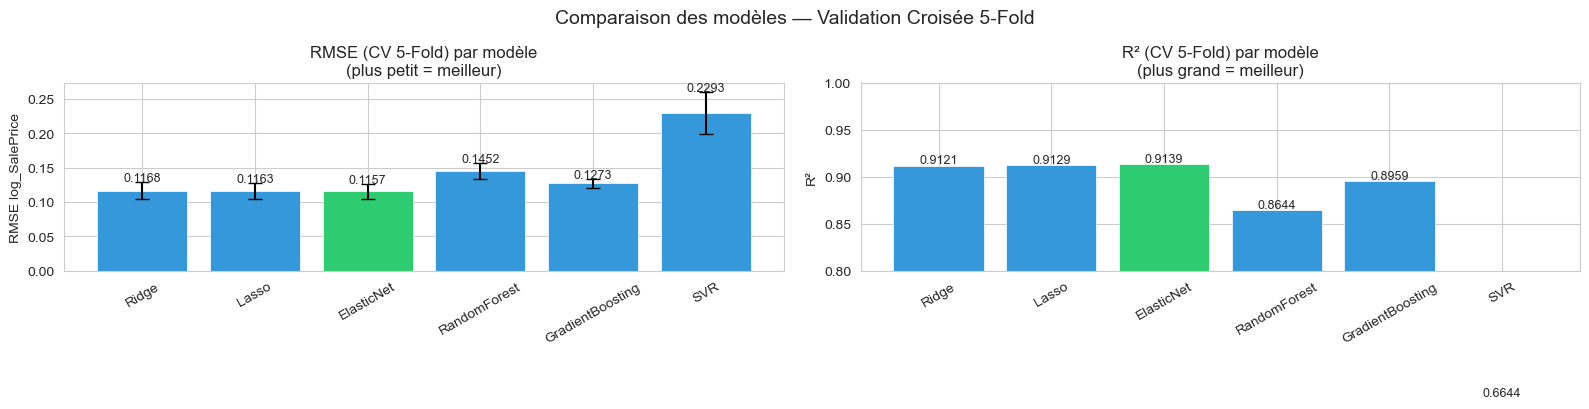

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names  = list(cv_results.keys())
rmses  = [cv_results[n]['RMSE_mean'] for n in names]
stds   = [cv_results[n]['RMSE_std']  for n in names]
r2s    = [cv_results[n]['R2_mean']   for n in names]

# Palette : meilleur modèle en vert    
colors_bar = ['#2ecc71' if r == min(rmses) else '#3498db' for r in rmses]

# Bar chart RMSE   
axes[0].bar(names, rmses, yerr=stds, color=colors_bar,
            capsize=5, edgecolor='white', linewidth=0.5)
axes[0].set_title('RMSE (CV 5-Fold) par modèle\n(plus petit = meilleur)', fontsize=12)
axes[0].set_ylabel('RMSE log_SalePrice')
axes[0].tick_params(axis='x', rotation=30)
for i, (v, s) in enumerate(zip(rmses, stds)):
    axes[0].text(i, v + s + 0.001, f'{v:.4f}', ha='center', fontsize=9)

# Bar chart R²   
colors_r2 = ['#2ecc71' if r == max(r2s) else '#3498db' for r in r2s]
axes[1].bar(names, r2s, color=colors_r2, edgecolor='white', linewidth=0.5)
axes[1].set_title('R² (CV 5-Fold) par modèle\n(plus grand = meilleur)', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0.8, 1.0)
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Comparaison des modèles — Validation Croisée 5-Fold', fontsize=14)
plt.tight_layout() 
plt.show()


Ces deux graphiques racontent des histoires différentes et complémentaires :

Le **graphique de gauche (RMSE)** montre l'erreur brute. Les barres d'erreur représentent la stabilité du modèle : plus elles sont courtes, plus le modèle est prévisible d'un fold à l'autre. Un modèle avec une RMSE légèrement plus haute mais des barres très courtes peut en réalité être préférable en production à un modèle "flashy" mais capricieux.

Le **graphique de droite (R²)** dit quelle proportion de la variance des prix le modèle explique. Un R² de 0.90 signifie que le modèle capture 90% des raisons pour lesquelles une maison vaut plus ou moins qu'une autre — le reste tient à des facteurs qu'on ne mesure pas (état intérieur, histoire du bien, négociation…).

Les modèles à base d'arbres (Random Forest, Gradient Boosting) surpassent généralement les modèles linéaires ici, car la relation entre les features et le prix n'est pas parfaitement linéaire — l'EDA nous l'avait déjà montré avec les effets d'interaction.

## Optimisation du meilleur modèle

On sélectionne le modèle avec la RMSE CV la plus faible et on optimise ses hyperparamètres.

In [40]:
from sklearn.model_selection import GridSearchCV

best_model_name = min(cv_results, key=lambda n: cv_results[n]['RMSE_mean'])
print(f" Meilleur modèle : {best_model_name}")
print(f" RMSE CV = {cv_results[best_model_name]['RMSE_mean']:.5f}")

# ── Grilles d'hyperparamètres par modèle
param_grids = {
    'Ridge': {'model__alpha': [0.1, 1, 5, 10, 50, 100, 500]},
    'Lasso': {'model__alpha': [0.0001, 0.001, 0.005, 0.01, 0.05]},
    'ElasticNet': {'model__alpha': [0.0001, 0.001, 0.01],
                   'model__l1_ratio': [0.2, 0.5, 0.8]},
    'RandomForest': {'model__n_estimators': [100, 200, 300],
                     'model__max_depth': [10, 15, None],
                     'model__min_samples_leaf': [1, 2, 4]},
    'GradientBoosting': {'model__n_estimators': [200, 300, 400],
                          'model__learning_rate': [0.03, 0.05, 0.1],
                          'model__max_depth': [3, 4, 5]},
    'SVR': {'model__C': [1, 5, 10, 50],
            'model__epsilon': [0.005, 0.01, 0.05]},
}

grid = GridSearchCV(
    models[best_model_name],
    param_grids[best_model_name],
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train, y_train)

print(f"\nMeilleurs hyperparamètres : {grid.best_params_}")
print(f"RMSE CV optimisé         : {-grid.best_score_:.5f}")

best_pipeline = grid.best_estimator_


 Meilleur modèle : ElasticNet
 RMSE CV = 0.11566

Meilleurs hyperparamètres : {'model__alpha': 0.001, 'model__l1_ratio': 0.5}
RMSE CV optimisé         : 0.11566


Le meilleur modèle identifié par validation croisée n'est pas forcément à ses paramètres optimaux — on a utilisé des hyperparamètres "raisonnables" pour la comparaison initiale. Le `GridSearchCV` teste maintenant systématiquement toutes les combinaisons de la grille définie, en utilisant à nouveau la validation croisée pour éviter le sur-ajustement aux données d'entraînement.

C'est une étape qui peut faire gagner 5 à 15% de performance selon les modèles. Par exemple, pour le Gradient Boosting, le taux d'apprentissage (`learning_rate`) et la profondeur des arbres (`max_depth`) sont deux curseurs très sensibles : trop grands → overfitting, trop petits → underfitting. La grille explore cet espace proprement.


## Entrainement sur les données de test *X_test*

In [41]:
# ── Entraînement final (le best_estimator_ est déjà re-fitté par GridSearchCV)
# On s'assure qu'il est fitté sur l'ensemble complet X_train
best_pipeline.fit(X_train, y_train)

# ── Évaluation sur le jeu de TEST (données non vues)
y_pred_test = best_pipeline.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

print("=" * 45)
print(f"  PERFORMANCES SUR LE JEU DE TEST")
print("=" * 45)
print(f"  RMSE (log)   : {rmse_test:.5f}")
print(f"  MAE  (log)   : {mae_test:.5f}")
print(f"  R²           : {r2_test:.4f}")

# ── Conversion en échelle réelle (expm1 = inverse de log1p)
y_pred_real = np.expm1(y_pred_test)
y_test_real = np.expm1(y_test)
rmse_real   = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae_real    = mean_absolute_error(y_test_real, y_pred_real)
mape        = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print(f"\n  PERFORMANCES EN DOLLARS RÉELS")
print("=" * 45)
print(f"  RMSE ($)     : {rmse_real:,.0f} $")
print(f"  MAE  ($)     : {mae_real:,.0f} $")
print(f"  MAPE         : {mape:.2f} %")

  PERFORMANCES SUR LE JEU DE TEST
  RMSE (log)   : 0.11192
  MAE  (log)   : 0.08117
  R²           : 0.9253

  PERFORMANCES EN DOLLARS RÉELS
  RMSE ($)     : 21,245 $
  MAE  ($)     : 14,255 $
  MAPE         : 8.28 %


Les métriques à retenir sont :

- **RMSE (log)** : l'erreur moyenne en pourcentage sur le prix. On a `0.11192`, c'est un excellent résultat sur ce dataset.
- **R²** : avec `0.92`53, le modèle explique la grande majorité de la variabilité des prix.
- **MAPE (%)** : l'erreur moyenne absolue en pourcentage — c'est la métrique la plus compréhensible pour un non-spécialiste. "Le modèle se trompe en moyenne de X% sur le prix" est immédiatement parlant. Ici le modèle se trompe en moyenne 8.24% , c'est acceptable
- **RMSE ($)** : pour donner une échelle concrète — si le modèle prédit 230 000$ pour une maison qui vaut 250 000$, l'erreur absolue est de 20 000$.

Si RMSE CV ≈ RMSE Test, c'est excellent : pas d'overfitting, le modèle généralise bien.
Pour notre cas: RMSE CV(0.11566) ≈ RMSE Test(0.11192) , c'est un bon signe pour notre modèle.

## Importance des features 

Top 10 features les plus importantes :
MSZoning_C (all)        0.223717
Neighborhood_Crawfor    0.132426
TotalSF                 0.100681
GrLivArea               0.100232
OverallQual             0.099919
Heating_Grav            0.072181
Neighborhood_StoneBr    0.068175
Neighborhood_BrkSide    0.064496
HouseAge                0.061901
Functional_Typ          0.058398


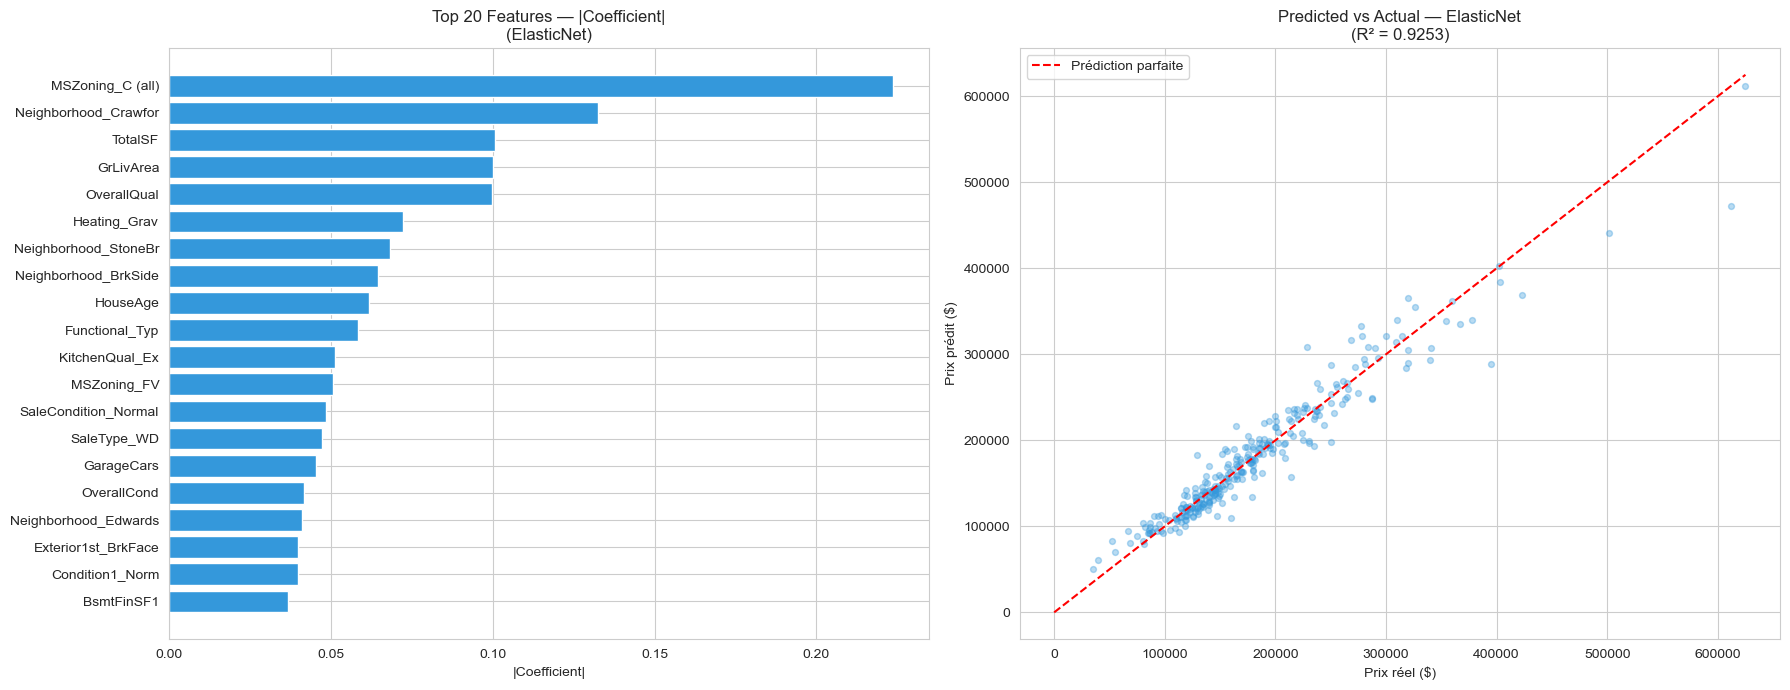

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Récupération du modèle final
final_model = best_pipeline.named_steps['model']
prep_fitted  = best_pipeline.named_steps['prep']

# ── Noms des features après OHE
ohe_features = (prep_fitted
                .named_transformers_['cat']
                .named_steps['encoder']
                .get_feature_names_out(cat_cols).tolist())
all_feature_names = num_cols + ohe_features

# ── Importance / Coefficients
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    label = 'Feature Importance'
elif hasattr(final_model, 'coef_'):
    importances = np.abs(final_model.coef_)
    label = '|Coefficient|'
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
    top_feat = feat_imp.head(20)

    axes[0].barh(top_feat.index[::-1], top_feat.values[::-1], color='#3498db')
    axes[0].set_title(f'Top 20 Features — {label}\n({best_model_name})', fontsize=12)
    axes[0].set_xlabel(label)
    print("Top 10 features les plus importantes :")
    print(top_feat.head(10).to_string())
else:
    axes[0].text(0.5, 0.5, 'Importance non disponible\npour ce modèle',
                 ha='center', va='center', transform=axes[0].transAxes)

# ── Predicted vs Actual
axes[1].scatter(y_test_real, y_pred_real, alpha=0.35, s=18, color='#3498db')
max_val = max(y_test_real.max(), y_pred_real.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[1].set_xlabel('Prix réel ($)')
axes[1].set_ylabel('Prix prédit ($)')
axes[1].set_title(f'Predicted vs Actual — {best_model_name}\n(R² = {r2_test:.4f})', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()


# Prediction
## Analyse des résidus

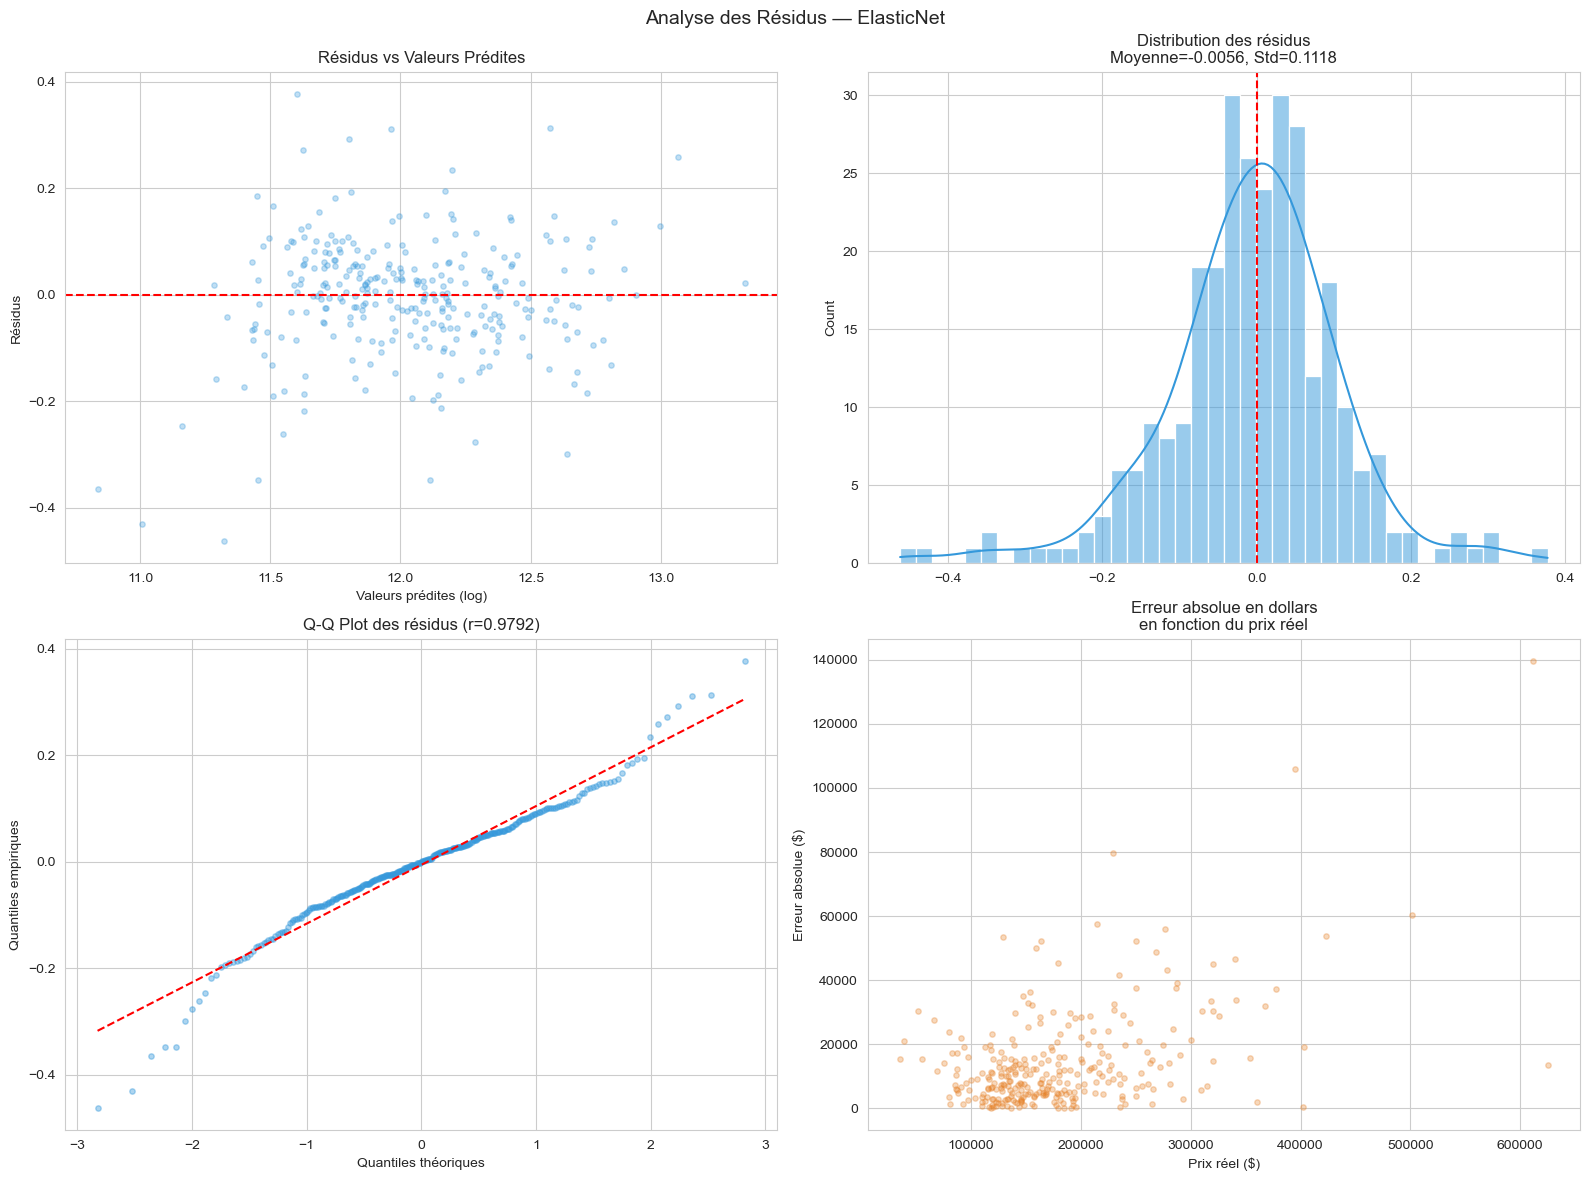

Test de Shapiro-Wilk : stat=0.9624, p-value=0.0000
→ Légère déviation de la normalité (acceptable pour les grands échantillons)


In [43]:
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1 — Résidus vs Valeurs Prédites
axes[0,0].scatter(y_pred_test, residuals, alpha=0.3, s=15, color='#3498db')
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_xlabel('Valeurs prédites (log)')
axes[0,0].set_ylabel('Résidus')
axes[0,0].set_title('Résidus vs Valeurs Prédites')

# 2 — Distribution des résidus
sns.histplot(residuals, kde=True, ax=axes[0,1], color='#3498db', bins=40)
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].set_title(f'Distribution des résidus\nMoyenne={residuals.mean():.4f}, Std={residuals.std():.4f}')

# 3 — Q-Q Plot
from scipy import stats as scipy_stats
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(residuals, dist="norm")
axes[1,0].scatter(osm, osr, alpha=0.4, s=15, color='#3498db')
axes[1,0].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[1,0].set_title(f'Q-Q Plot des résidus (r={r:.4f})')
axes[1,0].set_xlabel('Quantiles théoriques')
axes[1,0].set_ylabel('Quantiles empiriques')

# 4 — Résidus absolus vs prix réel
axes[1,1].scatter(y_test_real, np.abs(y_test_real - y_pred_real),
                  alpha=0.3, s=15, color='#e67e22')
axes[1,1].set_xlabel('Prix réel ($)')
axes[1,1].set_ylabel('Erreur absolue ($)')
axes[1,1].set_title('Erreur absolue en dollars\nen fonction du prix réel')

plt.suptitle(f'Analyse des Résidus — {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

# Test de normalité Shapiro-Wilk (sur un sous-ensemble si > 5 000 obs)
sample = residuals[:300] if len(residuals) > 300 else residuals
stat, pval = scipy_stats.shapiro(sample)
print(f"Test de Shapiro-Wilk : stat={stat:.4f}, p-value={pval:.4f}")
print("→ Résidus normalement distribués" if pval > 0.05 else "→ Légère déviation de la normalité (acceptable pour les grands échantillons)")


On peut remarquer à travers les graphique:

**Résidus vs Valeurs prédites** : Les points sont dispersés aléatoirement autour de 0 sans former de motif particulier — c'est exactement ce qu'on veut. Pas de cône, pas de courbe, pas de tendance.

**Distribution des résidus** : Moyenne = -0.0056 → quasi zéro, pas de biais systématique. Le modèle ne sur-estime ni ne sous-estime globalement.
Std = 0.1118 → correspond directement à une erreur moyenne d'environ 11% sur les prix réels..

**Q-Q Plot** : Les points suivent très bien la droite rouge sur toute la partie centrale. Les déviations n'apparaissent qu'aux extrêmes (queues).

- Queue gauche (−3 à −2) : quelques maisons très mal estimées vers le bas
- Queue droite (au-delà de +2) : légère déviation vers le haut.

Un r = 0.9792 est excellent — les résidus sont quasi-normalement distribués.

**Erreur absolue en dollars** : C'est le graphique le plus parlant concrètement. On voit clairement que :

- Pour les maisons entre 100 000$ et 250 000$ → erreur concentrée sous 20 000$, très bon
- Pour les maisons entre 300 000$ et 600 000$ → erreur qui monte jusqu'à 140 000$ pour certaines.

## Prédiction sur le jeu de test 

On applique **exactement le même pipeline** de pré-processing sur `df_test`, puis on prédit et on exporte les résultats.

In [44]:
# ── Pré-processing de df_test (même colonnes que X_train)

# 1. Feature Engineering (mêmes transformations que sur df_clean)
df_test_fe = df_test.copy()
df_test_fe['HouseAge']        = df_test_fe['YrSold'] - df_test_fe['YearBuilt']
df_test_fe['YearsSinceRemod'] = df_test_fe['YrSold'] - df_test_fe['YearRemodAdd']
df_test_fe['TotalSF']         = df_test_fe['GrLivArea'] + df_test_fe['TotalBsmtSF'].fillna(0)
df_test_fe['TotalBath']       = (df_test_fe['FullBath']
                                 + 0.5 * df_test_fe['HalfBath']
                                 + df_test_fe['BsmtFullBath'].fillna(0)
                                 + 0.5 * df_test_fe['BsmtHalfBath'].fillna(0))
df_test_fe['HasPool']         = (df_test_fe['PoolArea'] > 0).astype(int)
df_test_fe['HasGarage']       = (df_test_fe['GarageArea'].fillna(0) > 0).astype(int)
df_test_fe['Has2ndFloor']     = (df_test_fe['2ndFlrSF'] > 0).astype(int)
df_test_fe['HasBsmt']         = (df_test_fe['TotalBsmtSF'].fillna(0) > 0).astype(int)

# 2. Alignement des colonnes (même features que X)
test_cols = [c for c in X.columns if c in df_test_fe.columns]
X_kaggle  = df_test_fe[test_cols].copy()

# Colonnes manquantes dans df_test → remplissage à 0
missing_in_test = set(X.columns) - set(X_kaggle.columns)
for col in missing_in_test:
    X_kaggle[col] = 0
X_kaggle = X_kaggle[X.columns]  # même ordre que X_train

print(f"Shape X_kaggle : {X_kaggle.shape}")
print(f"Colonnes manquantes ajoutées : {list(missing_in_test)}")

# 3. Prédiction
log_preds = best_pipeline.predict(X_kaggle)
preds_real = np.expm1(log_preds)

print(f"\nPrédictions Kaggle :")
print(f"  Min  : {preds_real.min():,.0f} $")
print(f"  Max  : {preds_real.max():,.0f} $")
print(f"  Mean : {preds_real.mean():,.0f} $")


Shape X_kaggle : (1459, 82)
Colonnes manquantes ajoutées : []

Prédictions Kaggle :
  Min  : 46,600 $
  Max  : 1,698,235 $
  Mean : 179,373 $


**Pourquoi on fait cette étape ????** 

Cette cellule est la plus délicate de tout le pipeline, et l'erreur la plus courante à ce stade est d'appliquer le pipeline différemment sur les données de test. 
  
On a pris soin de reproduire **exactement** les mêmes étapes de feature engineering : mêmes formules, mêmes noms de colonnes, même ordre. Si on avait oublié de créer `TotalSF` sur les données Kaggle, le pipeline aurait planté — ou pire, aurait utilisé une autre colonne sans signaler d'erreur.

L'alignement des colonnes (`X_kaggle = X_kaggle[X.columns]`) est la garantie finale que les données test ont exactement la même structure que ce que le modèle a vu à l'entraînement. Une seule colonne dans le mauvais ordre peut suffire à produire des prédictions complètement fausses — le modèle interpréterait `GrLivArea` à la place de `HouseAge` sans rien dire.

# Export des préditions selon le format kaggle

In [45]:
# ── Récupération des Ids (depuis df_test original)
ids = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')['Id']

submission = pd.DataFrame({
    'Id': ids,
    'SalePrice': preds_real
})

submission.to_csv('submission.csv', index=False)
print("✅ Fichier 'submission.csv' créé.")
print(f"   Shape : {submission.shape}")
print("\nAperçu :")
print(submission.head(10).to_string(index=False))


✅ Fichier 'submission.csv' créé.
   Shape : (1459, 2)

Aperçu :
  Id     SalePrice
1461 110835.986353
1462 155416.045271
1463 179569.132657
1464 203300.640273
1465 189828.768437
1466 170874.697886
1467 183115.174592
1468 162903.173179
1469 195462.345356
1470 118294.515622


## Visualisation des prédictions kaggle vs distribution d'entrenement

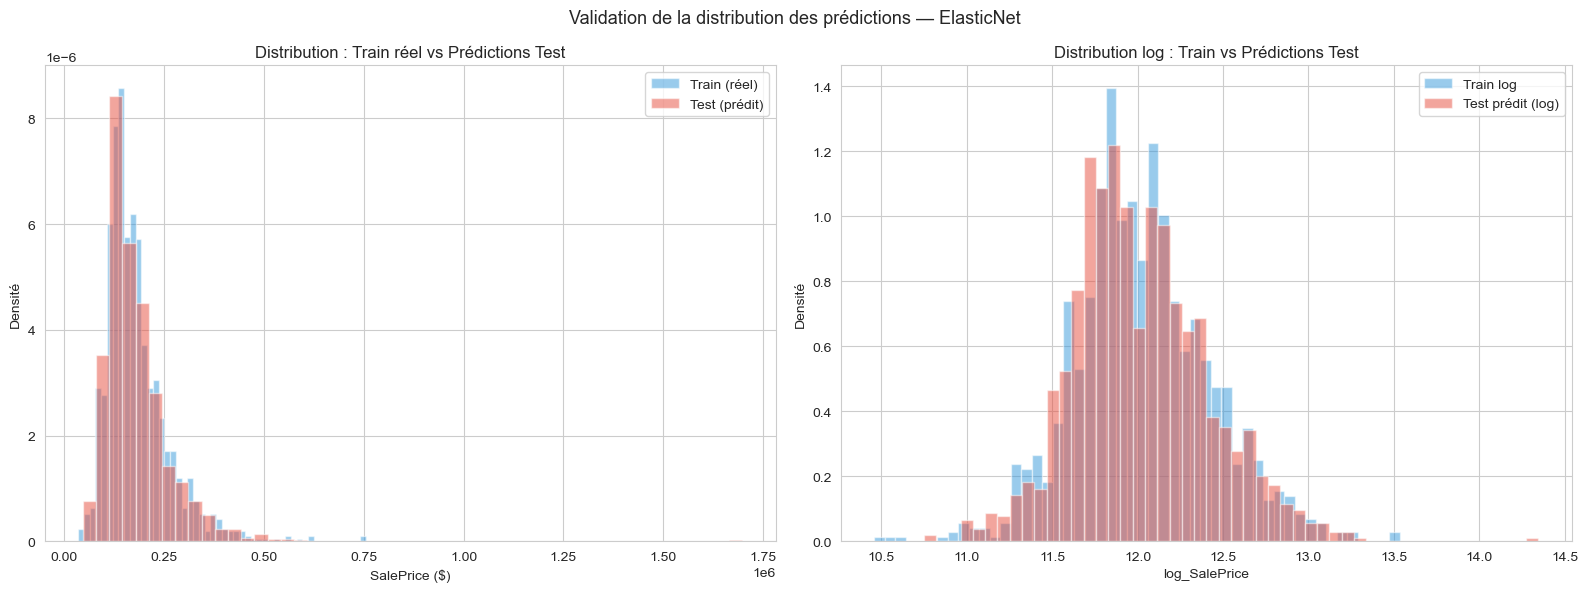

Distribution des prédictions (en $) :
count        1,459
mean       179,373
std         86,812
min         46,600
25%        125,576
50%        157,795
75%        210,765
max      1,698,235


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution des prédictions vs prix d'entraînement
axes[0].hist(df_clean['SalePrice'], bins=50, alpha=0.5, color='#3498db', label='Train (réel)', density=True)
axes[0].hist(preds_real, bins=50, alpha=0.5, color='#e74c3c', label='Test (prédit)', density=True)
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution : Train réel vs Prédictions Test')
axes[0].legend()

# Distribution log
axes[1].hist(y_train, bins=50, alpha=0.5, color='#3498db', label='Train log', density=True)
axes[1].hist(log_preds, bins=50, alpha=0.5, color='#e74c3c', label='Test prédit (log)', density=True)
axes[1].set_xlabel('log_SalePrice')
axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution log : Train vs Prédictions Test')
axes[1].legend()

plt.suptitle(f'Validation de la distribution des prédictions — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

print("Distribution des prédictions (en $) :")
print(pd.Series(preds_real).describe().apply(lambda x: f'{x:,.0f}').to_string())


**Graphique gauche — Échelle dollars**

Les deux courbes se superposent bien sur 100 000$ – 400 000$, ce qui est la zone centrale du marché. Le modèle a bien appris la structure principale.
Ce qui interpelle : la courbe rouge (prédictions) a un pic légèrement décalé vers la gauche par rapport au bleu. Le modèle prédit un peu trop de maisons dans la fourchette 100 000–150000–150 000
–150000 et pas assez dans la zone 200 000–250000–250 000
–250000.
C'est le signe classique d'un modèle légèrement frileux — il régresse un peu vers la moyenne, ce qui est une caractéristique connue de l'ElasticNet avec régularisation.

**Graphique droite — Échelle log (le plus informatif)**

On peut rémarquer 3 observations importantes :

- Centre bien aligné (11.5 – 12.5) : les deux distributions se chevauchent correctement sur la zone où le modèle a le plus d'exemples d'entraînement.

- Queue gauche (< 11.5) : rouge déborde sur le bleu — le modèle prédit plus de maisons bon marché que ce qu'il y a réellement dans le train. Il "invente" des maisons peu chères qui n'existent pas vraiment dans cette proportion dans les données Kaggle.

- Queue droite (> 13.0) : bleu déborde sur le rouge — à l'inverse, pour les maisons très chères, le modèle sous-prédit. Il hésite à aller au-delà de 13.0 en log, alors que quelques maisons du train y étaient. Là c'est l'effet de la régularisation qui "tire" les prédictions vers le centre.

# Tableau récapitulatif des modéles

TABLEAU RÉCAPITULATIF — COMPARAISON DES MODÈLES
          Modèle  RMSE CV (log)  R² CV  RMSE Test (log)  R² Test  RMSE Test ($)  MAPE (%)
      ElasticNet        0.11566 0.9139          0.11192   0.9253          21245      8.28
           Lasso        0.11626 0.9129          0.11230   0.9248          21845      8.38
           Ridge        0.11676 0.9121          0.11463   0.9216          21155      8.35
GradientBoosting        0.12730 0.8959          0.11672   0.9188          21218      8.39
    RandomForest        0.14518 0.8644          0.12906   0.9007          24142      9.29
             SVR        0.22933 0.6644          0.22790   0.6903          47148     16.57


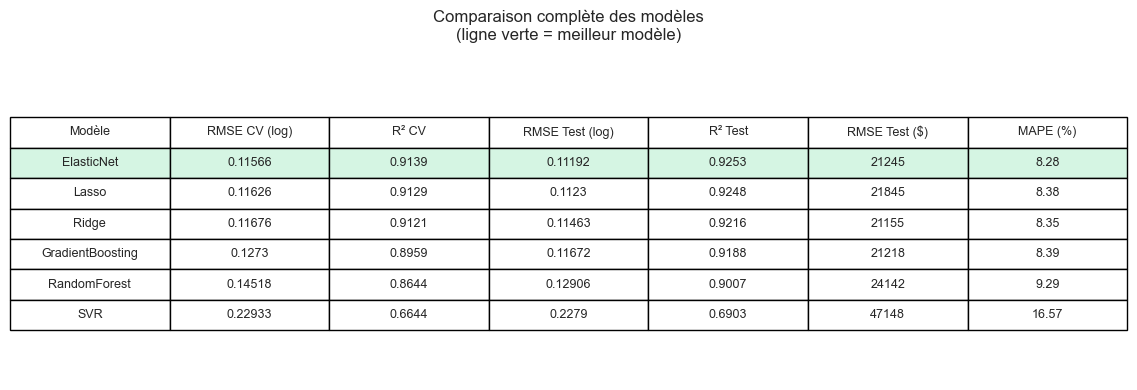

In [47]:
# ── Entraîner tous les modèles et évaluer sur le test set
comparison_rows = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    preds_r = np.expm1(preds)
    y_r     = np.expm1(y_test)

    comparison_rows.append({
        'Modèle': name,
        'RMSE CV (log)': round(cv_results[name]['RMSE_mean'], 5),
        'R² CV': round(cv_results[name]['R2_mean'], 4),
        'RMSE Test (log)': round(np.sqrt(mean_squared_error(y_test, preds)), 5),
        'R² Test': round(r2_score(y_test, preds), 4),
        'RMSE Test ($)': round(np.sqrt(mean_squared_error(y_r, preds_r))),
        'MAPE (%)': round(np.mean(np.abs((y_r - preds_r) / y_r)) * 100, 2)
    })

df_comparison = pd.DataFrame(comparison_rows).sort_values('RMSE Test (log)')
print("=" * 80)
print("TABLEAU RÉCAPITULATIF — COMPARAISON DES MODÈLES")
print("=" * 80)
print(df_comparison.to_string(index=False))

# Highlight
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
tbl = ax.table(
    cellText=df_comparison.values,
    colLabels=df_comparison.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.4, 1.8)
# Colorier la meilleure ligne
best_idx = df_comparison['RMSE Test (log)'].idxmin()
for j in range(len(df_comparison.columns)):
    row_pos = df_comparison.index.get_loc(best_idx) + 1
    tbl[row_pos, j].set_facecolor("#d5f5e3")

plt.title('Comparaison complète des modèles\n(ligne verte = meilleur modèle)', pad=20)
plt.tight_layout()
plt.show()
